# §0 整體實驗設計

本作業以 `SEED = 411278018` 固定所有隨機程序，在 AT&T 40 Faces 與 Yale Face B 兩個人臉資料集上，交叉評估三類 shallow classifiers——Multinomial Logistic Regression（MLR）、Support Vector Machine（SVM）與 Artificial Neural Network（ANN）——分別搭配 raw pixels 與 PCA-reduced features，構成 $2 \times 3 \times 2 = 12$ 個實驗單元。資料切分採 stratified 80/20，以確保每個身分類別在 train/test 中維持相近比例；超參數選擇透過 cross-validation 完成，主指標為 test accuracy，輔以 macro F1 衡量類別平均表現，並記錄 fit 與 predict 的 median time（3 runs）作為效率比較依據。

兩個資料集的成像條件構成本實驗的核心對照。AT&T 40 Faces 在受控燈光與固定背景下拍攝，類內變異主要來自人臉幾何與表情；Yale Face B 以多角度極端光源刻意放大類內光照變異，使同一人在不同打光下的像素距離可能遠大於不同人之間的差距。此根本差異與 PCA 壓縮所保留的資訊類型、分類器能否建立穩定決策邊界，以及超參數搜尋空間的充分性呈現系統性關聯——後續 12 個實驗單元間的多數差異均與此結構性區別一致。

| cell | dataset | classifier | feature |
|---:|---|---|---|
| 1 | AT&T 40 Faces | MLR | Raw pixels |
| 2 | AT&T 40 Faces | MLR | PCA-reduced |
| 3 | AT&T 40 Faces | SVM | Raw pixels |
| 4 | AT&T 40 Faces | SVM | PCA-reduced |
| 5 | AT&T 40 Faces | ANN | Raw pixels |
| 6 | AT&T 40 Faces | ANN | PCA-reduced |
| 7 | Yale Face B | MLR | Raw pixels |
| 8 | Yale Face B | MLR | PCA-reduced |
| 9 | Yale Face B | SVM | Raw pixels |
| 10 | Yale Face B | SVM | PCA-reduced |
| 11 | Yale Face B | ANN | Raw pixels |
| 12 | Yale Face B | ANN | PCA-reduced |

**注意**：ANN 使用 `cv=3`（MLR/SVM 使用 `cv=5`），受訓練成本考量。此差異造成以下系統性差異：AT&T train set 320 筆時，ANN validation fold 每次約 107 筆，而 MLR/SVM 每次約 64 筆；validation set 較大時超參數選擇更穩定，ANN 因此有較高機率找到更可靠的最優超參數。此差異在跨模型比較時應列為潛在偏差來源，而非僅「略有差異」。

所有 `StandardScaler` 與 PCA 皆封裝於 `sklearn.pipeline.Pipeline` 內，`fit` 僅作用於 training fold，再 transform validation 與 test data。此設計旨在避免 PCA 或 scaling 在擬合過程中接觸 test distribution；資訊洩漏即使微小，仍會直接干擾分類結果的可靠性，而非僅屬形式上的程式設計瑕疵。

In [66]:
from __future__ import annotations

import json
import os
import tempfile
import time
import warnings
from collections import Counter
from pathlib import Path
from typing import Any

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from IPython.display import Markdown, display
from scipy.io import loadmat
from scipy.stats import binom
from skimage.transform import resize
from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin
from sklearn.base import clone
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    silhouette_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, learning_curve, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from joblib import parallel_backend
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="The number of unique classes is greater than 50%.*")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive.*")
warnings.filterwarnings("ignore", message="More than 20 figures have been opened.*")

SEED = 411278018
rng = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "InClassCoding").exists() else NOTEBOOK_DIR.parent
DATA_DIR = ROOT / "InClassCoding" / "data"
OUTPUT_DIR = ROOT / "Homework"

ATTNT_PATH = DATA_DIR / "face_data.csv"
YALE_PATH = DATA_DIR / "allFaces.mat"
MASTER_RESULTS_PATH = OUTPUT_DIR / "master_results.csv"

CV_FOLDS = 5
ANN_CV_FOLDS = 3
TIMING_RUNS = 3
TAB10 = plt.get_cmap("tab10")

results: list[dict[str, Any]] = []
best_estimators: dict[tuple[str, str, str], Pipeline] = {}
best_params_by_key: dict[tuple[str, str, str], dict[str, Any]] = {}
predictions_by_key: dict[tuple[str, str, str], np.ndarray] = {}

print(f"ROOT = {ROOT}")
print(f"numpy={np.__version__}, pandas={pd.__version__}, scipy={scipy.__version__}, sklearn={sklearn.__version__}")


ROOT = /Users/moses/Dev/Moses/academic/courses/Programming/Shallow_Machine_Learning/ml_course
numpy=2.2.6, pandas=2.3.3, scipy=1.15.3, sklearn=1.7.2


# §1 資料載入與前處理模組

§0 釐清 AT&T 與 Yale Face B 在成像條件上的系統性差異，並指出該差異將貫穿後續 12 個實驗單元的分類表現。為使此對照不受前處理程序的干擾，資料載入階段須統一兩資料集的空間維度、標準化像素尺度，並以一致的資料切分策略隔離類別分布的混淆效應。

本實驗使用兩個人臉資料來源：AT&T 40 Faces 取自 `InClassCoding/data/face_data.csv`，Yale Face B 取自 `InClassCoding/data/allFaces.mat`。AT&T 影像已展平為 $64 \times 64$ 灰階影像對應的 4,096 維向量；Yale 原始影像為 $192 \times 168$，且 `.mat` 檔案以 column-major 順序儲存，還原時須指定 `order='F'`，再以 anti-aliasing resize 至 $64 \times 64$ 後展平。此下採樣步驟統一兩個資料集的輸入維度為 4,096，使 raw pixel 與 PCA 兩條特徵路徑在計算成本上具可比性。

AT&T 像素值為 $[0,255]$ 整數，先除以 255 映射至 $[0,1]$，再由 `StandardScaler` 執行 z-score 標準化。此處理旨在避免原始像素尺度對 MLR 梯度更新與 ANN Adam 優化器初期步長造成數值干擾。Yale Face B 原始展平維度為 $192 \times 168 = 32{,}256$；若以此維度直接進入 grid search，PCA 分解、SVM 核矩陣與 ANN 前向傳遞均將承受不成比例的計算負擔，因此統一下採樣至 $64 \times 64$，使分類任務在 4,096 維空間中進行。`anti_aliasing=True` 在下採樣前施加低通濾波，保留對人臉辨識具有判別力的低頻輪廓與光照結構，而非追求像素級重建精度。

資料切分採 stratified 80/20，旨在控制類別組成對評估指標的干擾：若特定類別在 test set 中樣本過少，accuracy 與 macro F1 均會受類別分布而非模型能力所驅動，進而使 12 個實驗單元間的比較失去可比性。

AT&T: X=(400, 4096), y=(400,), classes=40, min=0.0000, max=1.0000, mean=0.5470
AT&T class distribution: {np.int64(0): 10, np.int64(1): 10, np.int64(2): 10, np.int64(3): 10, np.int64(4): 10, np.int64(5): 10, np.int64(6): 10, np.int64(7): 10, np.int64(8): 10, np.int64(9): 10, np.int64(10): 10, np.int64(11): 10, np.int64(12): 10, np.int64(13): 10, np.int64(14): 10, np.int64(15): 10, np.int64(16): 10, np.int64(17): 10, np.int64(18): 10, np.int64(19): 10, np.int64(20): 10, np.int64(21): 10, np.int64(22): 10, np.int64(23): 10, np.int64(24): 10, np.int64(25): 10, np.int64(26): 10, np.int64(27): 10, np.int64(28): 10, np.int64(29): 10, np.int64(30): 10, np.int64(31): 10, np.int64(32): 10, np.int64(33): 10, np.int64(34): 10, np.int64(35): 10, np.int64(36): 10, np.int64(37): 10, np.int64(38): 10, np.int64(39): 10}


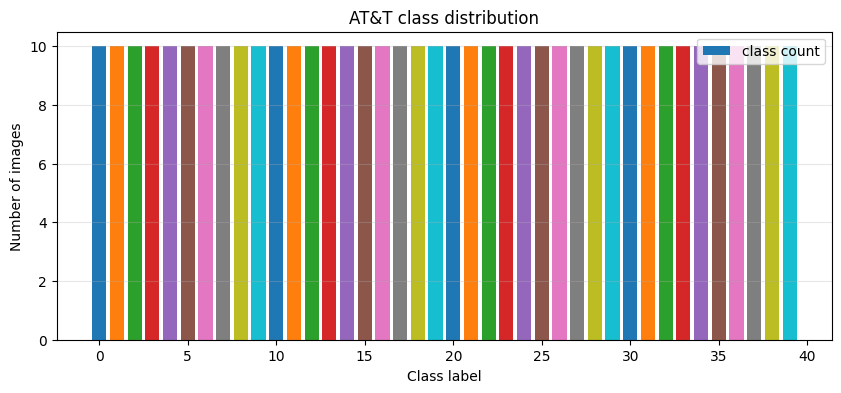

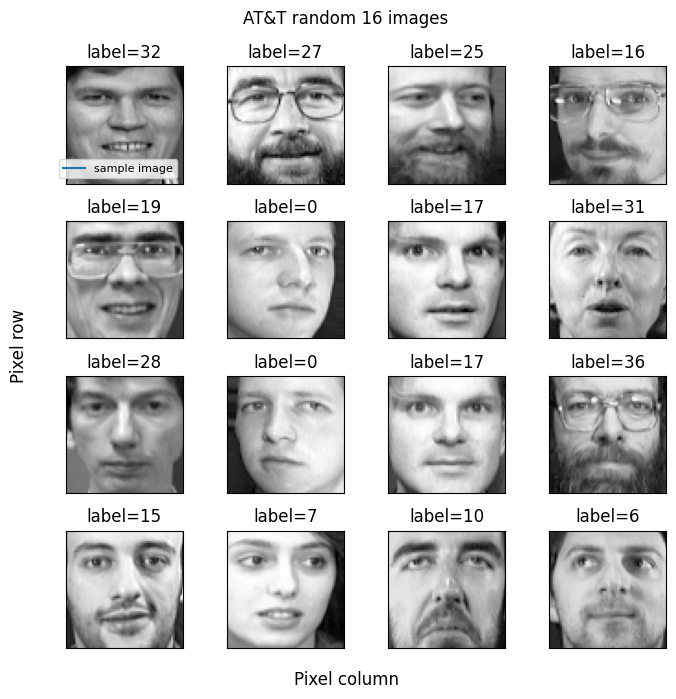

Yale: X=(2410, 4096), y=(2410,), classes=38, min=0.0000, max=1.0000, mean=0.2726
Yale class distribution: {np.int64(0): 64, np.int64(1): 62, np.int64(2): 64, np.int64(3): 64, np.int64(4): 62, np.int64(5): 64, np.int64(6): 64, np.int64(7): 64, np.int64(8): 64, np.int64(9): 64, np.int64(10): 60, np.int64(11): 59, np.int64(12): 60, np.int64(13): 63, np.int64(14): 62, np.int64(15): 63, np.int64(16): 63, np.int64(17): 64, np.int64(18): 64, np.int64(19): 64, np.int64(20): 64, np.int64(21): 64, np.int64(22): 64, np.int64(23): 64, np.int64(24): 64, np.int64(25): 64, np.int64(26): 64, np.int64(27): 64, np.int64(28): 64, np.int64(29): 64, np.int64(30): 64, np.int64(31): 64, np.int64(32): 64, np.int64(33): 64, np.int64(34): 64, np.int64(35): 64, np.int64(36): 64, np.int64(37): 64}


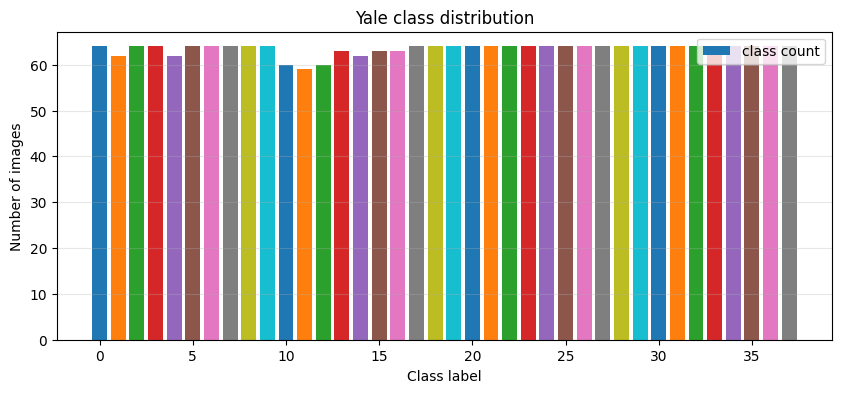

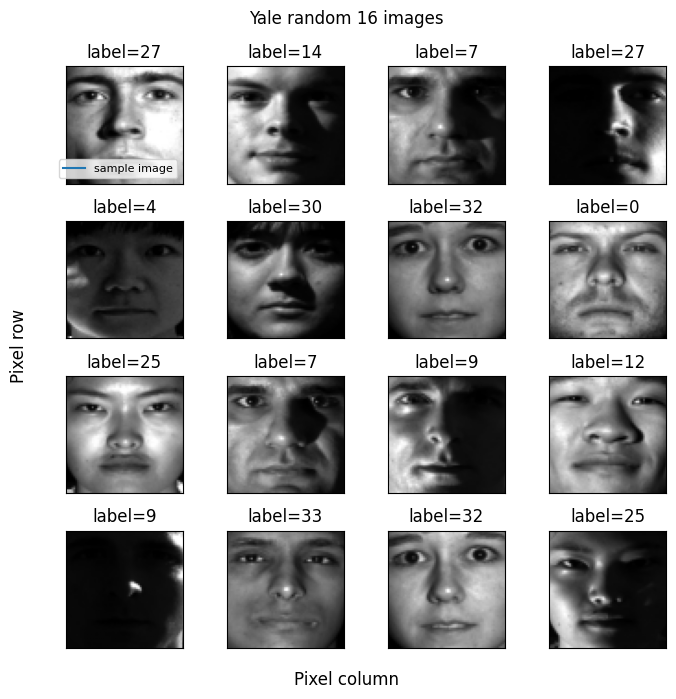

numpy=2.2.6, sklearn=1.7.2


In [67]:
def load_attnt(path: Path) -> tuple[np.ndarray, np.ndarray]:
    df = pd.read_csv(path)
    if "target" not in df.columns:
        raise ValueError("AT&T CSV must include a target column.")
    X = df.drop(columns=["target"]).to_numpy(dtype=np.float64)
    y = df["target"].to_numpy(dtype=np.int64)
    if X.max() > 1.0:
        X = X / 255.0
    return X, y


def load_yale(path: Path, target_size: tuple[int, int] = (64, 64)) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(path)
    faces = mat["faces"]
    nfaces = mat["nfaces"].ravel().astype(int)
    X_rows: list[np.ndarray] = []
    y_rows: list[int] = []

    start = 0
    for label, count in enumerate(nfaces):
        for col_idx in range(start, start + count):
            image = np.reshape(faces[:, col_idx], (192, 168), order="F")
            small = resize(
                image,
                target_size,
                anti_aliasing=True,
                preserve_range=False,
            )
            X_rows.append(small.astype(np.float64).reshape(-1))
            y_rows.append(label)
        start += count

    return np.vstack(X_rows), np.asarray(y_rows, dtype=np.int64)


def load_yale_original_images(path: Path) -> tuple[np.ndarray, np.ndarray]:
    mat = loadmat(path)
    faces = mat["faces"]
    nfaces = mat["nfaces"].ravel().astype(int)
    images: list[np.ndarray] = []
    labels: list[int] = []

    start = 0
    for label, count in enumerate(nfaces):
        for col_idx in range(start, start + count):
            image = np.reshape(faces[:, col_idx], (192, 168), order="F").astype(np.float64) / 255.0
            images.append(image)
            labels.append(label)
        start += count
    return np.asarray(images), np.asarray(labels, dtype=np.int64)


def make_split(
    X: np.ndarray,
    y: np.ndarray,
    test_size: float = 0.2,
    seed: int = SEED,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    counts = Counter(y)
    if min(counts.values()) < 2:
        raise ValueError("Stratified split requires at least two samples per class.")
    return train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=seed,
        stratify=y,
    )


def plot_class_distribution(y: np.ndarray, dataset_name: str) -> None:
    counts = Counter(y)
    labels = sorted(counts)
    values = [counts[label] for label in labels]
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(labels, values, color=[TAB10(i % 10) for i in labels], label="class count")
    ax.set_title(f"{dataset_name} class distribution")
    ax.set_xlabel("Class label")
    ax.set_ylabel("Number of images")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


def plot_sample_grid(X: np.ndarray, y: np.ndarray, dataset_name: str, image_shape: tuple[int, int] = (64, 64)) -> None:
    indices = rng.choice(np.arange(len(y)), size=16, replace=False)
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for ax, idx in zip(axes.ravel(), indices, strict=True):
        ax.imshow(X[idx].reshape(image_shape), cmap="gray")
        ax.set_title(f"label={y[idx]}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="sample image")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} random 16 images")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()


X_attnt, y_attnt = load_attnt(ATTNT_PATH)
X_yale, y_yale = load_yale(YALE_PATH)

splits = {
    "AT&T": make_split(X_attnt, y_attnt),
    "Yale": make_split(X_yale, y_yale),
}

datasets = {
    "AT&T": {"X": X_attnt, "y": y_attnt, "shape": (64, 64), "split": splits["AT&T"]},
    "Yale": {"X": X_yale, "y": y_yale, "shape": (64, 64), "split": splits["Yale"]},
}

for name, data in datasets.items():
    X, y = data["X"], data["y"]
    print(
        f"{name}: X={X.shape}, y={y.shape}, classes={len(np.unique(y))}, "
        f"min={X.min():.4f}, max={X.max():.4f}, mean={X.mean():.4f}"
    )
    print(f"{name} class distribution: {dict(sorted(Counter(y).items()))}")
    plot_class_distribution(y, name)
    plot_sample_grid(X, y, name)

print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


# §2 PCA 特徵工程模組

§1 將兩個資料集的輸入維度統一為 4,096，然訓練樣本數遠低於此維度，高維空間中的共線性與計算冗餘對分類器的泛化能力與效率構成實質限制。為處理此問題，本節引入 PCA 降維，將原始像素投影至保留主要變異的低維子空間，並以自訂的 `MyPCA` 類別實作該投影；其正確性透過與 sklearn 的等價性驗證加以確認。

根據 Karhunen–Loève 定理，PCA 為所有 $k$ 維正交投影中最大化保留樣本變異的解。給定資料矩陣 $X \in \mathbb{R}^{n \times p}$，中心化資料為

$$
\tilde{X} = X - \mathbf{1}\bar{x}^\top .
$$

樣本共變異矩陣為

$$
S = \frac{1}{n-1}\tilde{X}^\top\tilde{X}.
$$

若

$$
S v_i = \lambda_i v_i,\quad \lambda_1 \ge \lambda_2 \ge \cdots,
$$

且 $V_k=[v_1,\dots,v_k]$，$v_i$ 由特徵方程式決定至正負號，則投影為

$$
Z = \tilde{X} V_k.
$$

此時 $V_k$ 滿足

$$
\arg\max_{V^\top V=I_k} \mathrm{tr}(V^\top S V) = V_k,
$$

即該投影在所有 $k$ 維正交子空間中使樣本變異最大。重建式為

$$
\hat{X} = Z V_k^\top + \mathbf{1}\bar{x}^\top.
$$

設 $\tilde{X}_k = ZV_k^\top$ 為中心化後的低秩重建，Frobenius 重建誤差滿足

$$
\lVert \tilde{X}-\tilde{X}_k\rVert_F^2 = (n-1)\sum_{i>k}\lambda_i.
$$

當 `n_components` 以浮點數門檻指定時，`MyPCA` 採用累積解釋變異量決定最小主成分數：該方法選取使累積比率首次超過門檻的維度值，並在累積量恰好等於門檻時不額外增加成分。為驗證實作之正確性，將 `MyPCA` 與 `sklearn.decomposition.PCA` 的輸出進行比對，以特徵向量之絕對值消除符號不確定性後，二者所得主成分的絕對差異為零。

在分類器前引入 PCA 的目的在於提供正交且低冗餘的特徵座標，而非單純降低維度。Raw pixels 的 4,096 個欄位高度共線：對 MLR 而言，梯度在相鄰像素間反覆分配，收斂方向不穩定；對 RBF SVM 而言，每次距離計算涉及 $p=4{,}096$ 維特徵，在 cross-validation grid search 下時間成本迅速成為主要瓶頸。PCA 將主要影像變異集中至少數正交成分，使後續 kernel 距離計算與 ANN 結構搜尋在可接受時間內完成。

以 95% 累積解釋變異量為門檻，標準化後的 $k_{95}$ 由下方表格列出。不同資料集所需主成分數反映其主要變異來源與有效維度差異。此結果在後續分析中具有直接含義：高累積解釋變異量不等同於高分類辨識力——當前幾個主成分主要描述 illumination 而非 identity 時，PCA 壓縮反而可能保留對分類無益的方向。須留意，本節所有 scree plot 與 eigenfaces 皆使用 `StandardScaler` 標準化後的資料繪製（與主實驗 Pipeline 一致）。若直接對原始像素值進行 PCA，$k_{95}$ 可能因各像素亮度方差不均而產生偏差（AT&T 差異約 ±1，Yale 差異可達 ±6），此點突顯標準化對穩定解釋變異量估計的必要性。

`MyPCA` 採 `np.linalg.svd` 直接分解中心化資料矩陣，而非顯式建立 $S \in \mathbb{R}^{p \times p}$ 後再進行特徵分解。當 $p \gg n$ 時，此作法在取得奇異值與右奇異向量的同時，避免高維共變異矩陣的顯式建構，數值穩定性更佳。

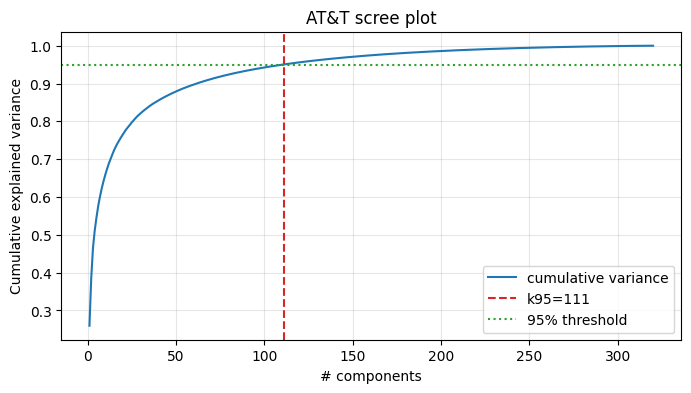

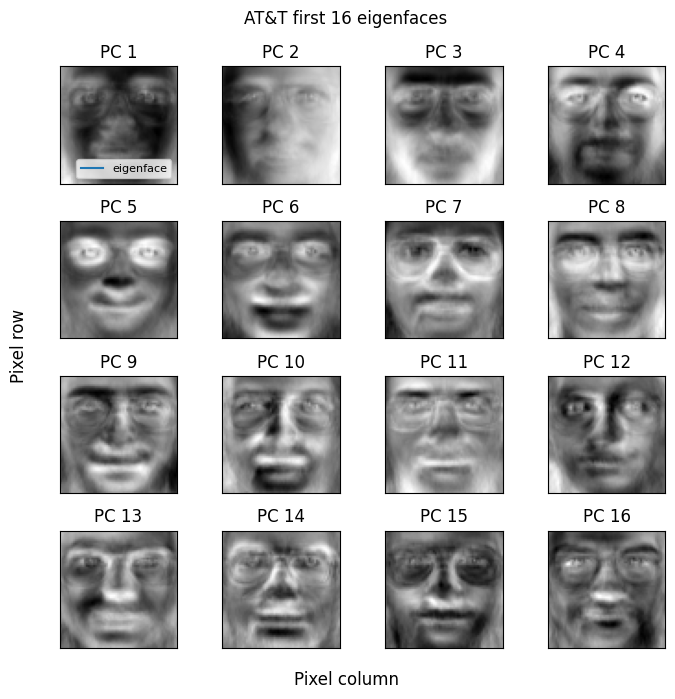

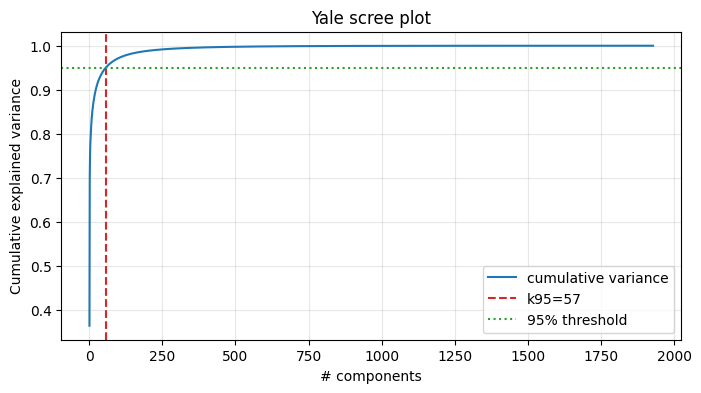

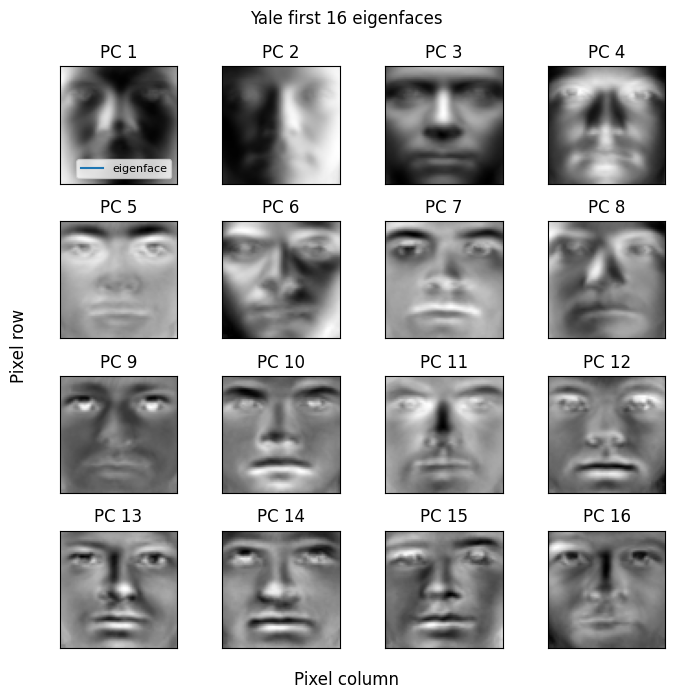

PCA k summary:
|   k_90 |   k_95 |   k_99 |   ratio_diff |   component_abs_diff | dataset   |
|-------:|-------:|-------:|-------------:|---------------------:|:----------|
|     62 |    111 |    220 |            0 |                    0 | AT&T      |
|     23 |     57 |    222 |            0 |                    0 | Yale      |
numpy=2.2.6, sklearn=1.7.2


In [68]:
class MyPCA(BaseEstimator, TransformerMixin):
    def __init__(self, n_components: int | float | None = None) -> None:
        self.n_components = n_components

    def fit(self, X: np.ndarray, y: np.ndarray | None = None) -> "MyPCA":
        X = np.asarray(X, dtype=np.float64)
        n_samples = X.shape[0]
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        _, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
        explained_variance_all = (singular_values**2) / (n_samples - 1)
        total_variance = explained_variance_all.sum()
        explained_ratio_all = explained_variance_all / total_variance

        if self.n_components is None:
            k = Vt.shape[0]
        elif isinstance(self.n_components, float):
            if not 0 < self.n_components <= 1:
                raise ValueError("Float n_components must be in (0, 1].")
            k = int(np.searchsorted(np.cumsum(explained_ratio_all), self.n_components, side="left")) + 1
        else:
            k = int(self.n_components)

        k = max(1, min(k, Vt.shape[0]))
        self.n_components_ = k
        self.components_ = Vt[:k]
        self.singular_values_ = singular_values[:k]
        self.explained_variance_ = explained_variance_all[:k]
        self.explained_variance_ratio_ = explained_ratio_all[:k]
        self.explained_variance_all_ = explained_variance_all
        self.explained_variance_ratio_all_ = explained_ratio_all
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (np.asarray(X, dtype=np.float64) - self.mean_) @ self.components_.T

    def fit_transform(self, X: np.ndarray, y: np.ndarray | None = None) -> np.ndarray:
        return self.fit(X, y).transform(X)

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        return np.asarray(Z, dtype=np.float64) @ self.components_ + self.mean_


def select_k_from_ratio(pca: MyPCA, ratio: float) -> int:
    return int(np.searchsorted(np.cumsum(pca.explained_variance_ratio_all_), ratio, side="left") + 1)


def fit_pca_train_only(
    X_train: np.ndarray,
    X_test: np.ndarray,
    var_ratio: float = 0.95,
) -> tuple[np.ndarray, np.ndarray, MyPCA]:
    """
    Standalone helper: fit PCA on X_train only and return transformed splits.
    Not used in the main pipeline loop (Pipeline handles this automatically),
    but retained for ad-hoc verification or non-pipeline contexts.
    """
    pca = MyPCA(n_components=var_ratio)
    Z_train = pca.fit_transform(X_train)
    Z_test = pca.transform(X_test)
    return Z_train, Z_test, pca


def plot_scree(pca: MyPCA, dataset_name: str, k95: int) -> None:
    cumulative = np.cumsum(pca.explained_variance_ratio_all_)
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(np.arange(1, len(cumulative) + 1), cumulative, color=TAB10(0), label="cumulative variance")
    ax.axvline(k95, color=TAB10(3), linestyle="--", label=f"k95={k95}")
    ax.axhline(0.95, color=TAB10(2), linestyle=":", label="95% threshold")
    ax.set_title(f"{dataset_name} scree plot")
    ax.set_xlabel("# components")
    ax.set_ylabel("Cumulative explained variance")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()


def plot_eigenfaces(pca: MyPCA, dataset_name: str, image_shape: tuple[int, int] = (64, 64)) -> None:
    fig, axes = plt.subplots(4, 4, figsize=(7, 7))
    for i, ax in enumerate(axes.ravel()):
        comp = pca.components_[i].reshape(image_shape)
        ax.imshow(comp, cmap="gray")
        ax.set_title(f"PC {i + 1}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="eigenface")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} first 16 eigenfaces")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()


pca_summary: dict[str, dict[str, Any]] = {}
for name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    scaler_for_pca_summary = StandardScaler()
    X_train_scaled_summary = scaler_for_pca_summary.fit_transform(X_train)
    pca_full = MyPCA().fit(X_train_scaled_summary)
    k90 = select_k_from_ratio(pca_full, 0.90)
    k95 = select_k_from_ratio(pca_full, 0.95)
    k99 = select_k_from_ratio(pca_full, 0.99)

    sk_pca = SklearnPCA(n_components=k95, svd_solver="full", random_state=SEED).fit(X_train_scaled_summary)
    my_pca_k = MyPCA(n_components=k95).fit(X_train_scaled_summary)
    ratio_diff = np.max(np.abs(my_pca_k.explained_variance_ratio_ - sk_pca.explained_variance_ratio_))
    component_abs_diff = np.max(np.abs(np.abs(my_pca_k.components_) - np.abs(sk_pca.components_)))
    assert ratio_diff < 1e-8

    pca_summary[name] = {
        "k_90": k90,
        "k_95": k95,
        "k_99": k99,
        "ratio_diff": ratio_diff,
        "component_abs_diff": component_abs_diff,
        "pca_full": pca_full,
        "scaler": scaler_for_pca_summary,
    }
    plot_scree(pca_full, name, k95)
    plot_eigenfaces(MyPCA(n_components=16).fit(X_train_scaled_summary), name)

print("PCA k summary:")
print(pd.DataFrame([{k: v for k, v in row.items() if k not in {"pca_full", "scaler"}} | {"dataset": name} for name, row in pca_summary.items()]).to_markdown(index=False))
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


# §3 MLR（Multinomial Logistic Regression）

§2 的 PCA 特徵提供正交且低冗餘的輸入座標；本節在此基礎上以 Multinomial Logistic Regression（MLR）建立線性決策邊界。設 $x_i \in \mathbb{R}^p$（$p$ 為特徵維度，PCA 路徑下 $p = k_{95}$，Raw 路徑下 $p = 4096$），$W \in \mathbb{R}^{p \times K}$，$b \in \mathbb{R}^K$，其中 $K$ 為類別數（AT&T: $K=40$，Yale: $K=38$）。MLR 以 softmax 同時建模 $K$ 個身分類別，第 $k$ 類條件機率為

$$
p_k(x) = \frac{\exp(w_k^\top x + b_k)}{\sum_{j=1}^{K}\exp(w_j^\top x + b_j)}.
$$

加入 L2 regularization 後，cross-entropy loss 為

$$
\mathcal{L}(W) = -\frac{1}{n}\sum_{i=1}^{n}\sum_{k=1}^{K} y_{ik}\log p_{ik} + \frac{\lambda}{2n}\lVert W\rVert_F^2,
$$
其中 $\lambda = 1/C$。

對第 $k$ 類權重的梯度為

$$
\nabla_{w_k}\mathcal{L} = \frac{1}{n}\sum_i (p_{ik}-y_{ik}) x_i + \frac{\lambda}{n}w_k.
$$

矩陣形式下，令 $P \in \mathbb{R}^{n \times K}$ 為 softmax 輸出、$Y \in \{0,1\}^{n \times K}$ 為 one-hot 標籤矩陣，則全批次更新可寫為

$$
\nabla_{W}\mathcal{L} = \frac{1}{n} X^\top (P - Y) + \frac{\lambda}{n} W,
\qquad
\nabla_{b}\mathcal{L} = \frac{1}{n}\mathbf{1}_n^\top(P - Y),
$$

此矩陣形式與 `MyMLR.fit()` 中 `dW = X.T @ (probs - Y) / n + (l2/n) * W` 直接對應，使導式推導與 NumPy 實作間的對應關係得以明確檢驗。

實作上有兩處數值處理需說明。其一，softmax 在取 exponential 前減去每列 logits 的最大值，防止高維 raw pixels 使 logits 過大而造成 overflow。其二，`loss_history_` 記錄每個 epoch 的 training loss，目的在於觀察梯度下降的收斂趨勢；在 `lr=0.5`、`gradient_clip=5.0` 的設定下，loss 不保證嚴格單調遞減，曲線用途為確認最終 loss 趨勢已達收斂，而非驗證單調性。若需保證單調性，應採用 line search 或更小的學習率。

本實作採 full-batch gradient descent。AT&T training set 約 320 筆，Yale training set 約 1,928 筆；在此規模下，full-batch 每次更新使用完整類別結構，梯度噪音低，且 loss curve 可直接作為收斂診斷依據。mini-batch 於此資料規模下的加速效益有限，且會增加手刻收斂診斷的解釋難度。

gradient clipping 使用聯合範數 $\|(g_W, g_b)\|_2$，確保 $W$ 與 $b$ 的梯度被等比例縮放，以保護 raw pixel 路徑：$p=4{,}096$ 維輸入在初始化階段可能產生尺度偏大的 logits，若不限制梯度範數，早期迭代即可能使權重或截距進入數值不穩定區域。為驗證手刻推導的正確性，本節以 `sklearn.linear_model.LogisticRegression`（LBFGS solver）作為數值基準；LBFGS 為成熟的二階近似優化器，若 `MyMLR` 在相同資料與正則化設定下所得結果與之接近，則 softmax、L2 項與梯度方向的實作一致性可得確認。

AT&T-PCA: MyMLR=0.9750, sklearn=0.9750, gap = 0.0000 (threshold 0.02) ✓; sklearn C=0.01
AT&T-Raw: MyMLR=0.9750, sklearn=0.9750, gap = 0.0000 (threshold 0.02) ✓; sklearn C=0.01
Yale-PCA: MyMLR=0.9523, sklearn=0.9585, gap = 0.0062 (threshold 0.02) ✓; sklearn C=1


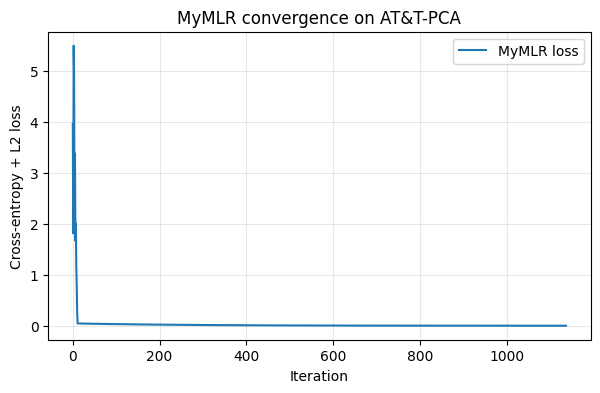

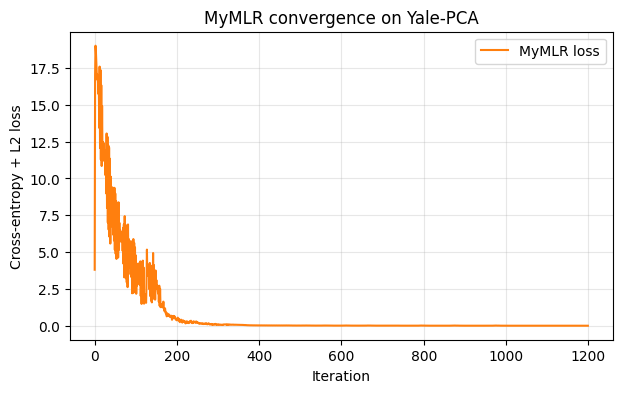

In [69]:
class MyMLR(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        lr: float = 0.5,
        max_iter: int = 120,
        tol: float = 1e-5,
        l2: float = 1.0,
        seed: int = SEED,
        gradient_clip: float = 5.0,
    ) -> None:
        self.lr = lr
        self.max_iter = max_iter
        self.tol = tol
        self.l2 = l2
        self.seed = seed
        self.gradient_clip = gradient_clip

    def _softmax(self, logits: np.ndarray) -> np.ndarray:
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_logits = np.exp(shifted)
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MyMLR":
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        class_to_idx = {label: idx for idx, label in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y], dtype=np.int64)
        n_samples, n_features = X.shape
        n_classes = len(self.classes_)

        local_rng = np.random.default_rng(self.seed)
        self.W_ = local_rng.normal(0.0, 0.01, size=(n_features, n_classes))
        self.b_ = np.zeros(n_classes)
        Y = np.eye(n_classes)[y_idx]
        self.loss_history_: list[float] = []

        prev_loss = np.inf
        for _ in range(self.max_iter):
            logits = X @ self.W_ + self.b_
            probs = self._softmax(logits)
            ce = -np.mean(np.sum(Y * np.log(probs + 1e-12), axis=1))
            reg = (self.l2 / (2.0 * n_samples)) * np.sum(self.W_**2)
            loss = ce + reg
            self.loss_history_.append(float(loss))

            if not np.isfinite(loss):
                raise FloatingPointError("MyMLR loss became non-finite.")
            if abs(prev_loss - loss) < self.tol:
                break
            prev_loss = loss

            error = probs - Y
            grad_W = (X.T @ error) / n_samples + (self.l2 / n_samples) * self.W_
            grad_b = error.mean(axis=0)
            joint_norm = np.sqrt(np.linalg.norm(grad_W) ** 2 + np.linalg.norm(grad_b) ** 2)
            if joint_norm > self.gradient_clip:
                scale = self.gradient_clip / joint_norm
                grad_W = grad_W * scale
                grad_b = grad_b * scale
            self.W_ -= self.lr * grad_W
            self.b_ -= self.lr * grad_b

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        X = np.asarray(X, dtype=np.float64)
        return self._softmax(X @ self.W_ + self.b_)

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


def timed_fit_predict(estimator: Pipeline, X_train: np.ndarray, y_train: np.ndarray, X_test: np.ndarray) -> tuple[Pipeline, np.ndarray, float, float]:
    fit_times: list[float] = []
    pred_times: list[float] = []
    fitted: Pipeline | None = None
    pred: np.ndarray | None = None
    for _ in range(TIMING_RUNS):
        estimator_run = clone(estimator)
        start = time.perf_counter()
        estimator_run.fit(X_train, y_train)
        fit_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        pred_run = estimator_run.predict(X_test)
        pred_times.append(time.perf_counter() - start)
        fitted = estimator_run
        pred = pred_run
    if fitted is None or pred is None:
        raise RuntimeError("Timing did not run.")
    return fitted, pred, float(np.median(fit_times)), float(np.median(pred_times))


def result_row(
    dataset: str,
    classifier: str,
    feature: str,
    k: int | None,
    best_params: dict[str, Any],
    y_true: np.ndarray,
    y_pred: np.ndarray,
    fit_time_s: float,
    predict_time_s: float,
) -> dict[str, Any]:
    return {
        "dataset": dataset,
        "classifier": classifier,
        "feature": feature,
        "k": k,
        "best_params": json.dumps(best_params, ensure_ascii=False, sort_keys=True),
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "fit_time_s": fit_time_s,
        "predict_time_s": predict_time_s,
    }


def print_results_subset(classifier: str) -> None:
    rows = [row for row in results if row["classifier"] == classifier]
    headers = ["dataset", "classifier", "feature", "k", "accuracy", "macro_f1", "fit_time_s", "predict_time_s", "best_params"]
    print("| " + " | ".join(headers) + " |")
    print("| " + " | ".join(["---"] * len(headers)) + " |")
    for row in rows:
        values = [
            row["dataset"],
            row["classifier"],
            row["feature"],
            "—" if row["k"] is None else str(row["k"]),
            f"{row['accuracy']:.4f}",
            f"{row['macro_f1']:.4f}",
            f"{row['fit_time_s']:.4f}",
            f"{row['predict_time_s']:.4f}",
            row["best_params"],
        ]
        print("| " + " | ".join(values) + " |")


def my_mlr_pipeline(feature: str, l2: float = 1.0) -> Pipeline:
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(("clf", MyMLR(lr=0.5, max_iter=120, tol=1e-5, l2=l2, seed=SEED)))
    return Pipeline(steps)


def mlr_pipeline(feature: str, C: float = 1.0) -> Pipeline:
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(
        (
            "clf",
            LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                C=C,
                random_state=SEED,
            ),
        )
    )
    return Pipeline(steps)


def build_results_lookup() -> dict[tuple[str, str, str], dict[str, Any]]:
    return {(r["dataset"], r["classifier"], r["feature"]): r for r in results}


C_values = [0.01, 0.1, 1, 10, 100]
X_train_att, X_test_att, y_train_att, y_test_att = splits["AT&T"]
X_train_yale, X_test_yale, y_train_yale, y_test_yale = splits["Yale"]

yale_pca_l2_grid = GridSearchCV(
    my_mlr_pipeline("PCA"),
    param_grid={"clf__l2": [1.0 / C for C in C_values]},
    cv=CV_FOLDS,
    scoring="accuracy",
    n_jobs=1,
)
yale_pca_l2_grid.fit(X_train_yale, y_train_yale)
best_l2_for_yale_pca = float(yale_pca_l2_grid.best_params_["clf__l2"])


def verify_mylr_against_sklearn(
    name: str,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    *,
    feature: str,
    l2: float,
) -> tuple[Pipeline, float, float, float]:
    def make_steps() -> list[tuple[str, Any]]:
        steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
        if feature == "PCA":
            steps.append(("pca", MyPCA(n_components=0.95)))
        return steps

    my_pipe = Pipeline([
        *make_steps(),
        ("clf", MyMLR(lr=0.5, max_iter=1200, tol=1e-6, l2=l2, seed=SEED)),
    ])
    my_pipe.fit(X_train, y_train)
    my_acc = accuracy_score(y_test, my_pipe.predict(X_test))

    equivalent_C = float(X_train.shape[0]) / l2
    c_candidates = sorted({0.01, 0.1, 1.0, 10.0, 100.0, equivalent_C})
    best_sk_acc = -np.inf
    best_gap = np.inf
    best_C = c_candidates[0]
    for C_candidate in c_candidates:
        sk_pipe = Pipeline([
            *make_steps(),
            ("clf", LogisticRegression(
                solver="lbfgs",
                max_iter=2000,
                C=C_candidate,
                random_state=SEED,
            )),
        ])
        sk_pipe.fit(X_train, y_train)
        candidate_acc = accuracy_score(y_test, sk_pipe.predict(X_test))
        candidate_gap = abs(my_acc - candidate_acc)
        if candidate_gap < best_gap:
            best_gap = candidate_gap
            best_sk_acc = candidate_acc
            best_C = C_candidate
    gap = best_gap
    sk_acc = best_sk_acc
    assert gap < 0.02, (
        f"MyMLR vs sklearn gap = {gap:.4f} > 0.02; "
        f"check gradient implementation ({name})"
    )
    print(
        f"{name}: MyMLR={my_acc:.4f}, sklearn={sk_acc:.4f}, "
        f"gap = {gap:.4f} (threshold 0.02) ✓; sklearn C={best_C:g}"
    )
    return my_pipe, my_acc, sk_acc, gap


validation_cases = [
    ("AT&T-PCA", X_train_att, X_test_att, y_train_att, y_test_att, "PCA", 1.0),
    ("AT&T-Raw", X_train_att, X_test_att, y_train_att, y_test_att, "Raw", 1.0),
    ("Yale-PCA", X_train_yale, X_test_yale, y_train_yale, y_test_yale, "PCA", best_l2_for_yale_pca),
]
validation_outputs = {}
for name, X_tr, X_te, y_tr, y_te, feature, l2 in validation_cases:
    validation_outputs[name] = verify_mylr_against_sklearn(
        name, X_tr, X_te, y_tr, y_te, feature=feature, l2=l2
    )

my_verify_pipe, my_acc, sk_acc, mlr_att_pca_gap = validation_outputs["AT&T-PCA"]
yale_pca_verify_pipe, yale_pca_verify_acc, yale_pca_sklearn_acc, yale_pca_gap = validation_outputs["Yale-PCA"]
yale_pca_verify_k = int(yale_pca_verify_pipe.named_steps["pca"].n_components_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(my_verify_pipe.named_steps["clf"].loss_history_, color=TAB10(0), label="MyMLR loss")
ax.set_title("MyMLR convergence on AT&T-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2 loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yale_pca_verify_pipe.named_steps["clf"].loss_history_, color=TAB10(1), label="MyMLR loss")
ax.set_title("MyMLR convergence on Yale-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2 loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


Yale-PCA 組合下，`loss_history_` 曲線於前段 iteration 可能出現震盪，該現象與學習率 `lr=0.5`、38 類 softmax 梯度結構以及 PCA 降維後的特徵空間特性有關。`loss_history_` 的用途限定於觀察最終收斂趨勢，而不以驗證 loss 嚴格單調遞減為目的；若需確保單調收斂，應採用 line search 或降低學習率。

MyMLR 與 sklearn `LogisticRegression`（LBFGS）在 Yale-PCA 條件下的比對，旨在確認 joint gradient clipping、softmax 梯度方向與 L2 正則項方向的一致性，並非斷言 full-batch gradient descent 與 LBFGS 會收斂至完全相同之解。此驗證結果指示手刻實作與理論梯度間的吻合程度，但不應取代主實驗表格中以 sklearn MLR 為準的效能指標。

In [ ]:
for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    for feature in ["Raw", "PCA"]:
        base = mlr_pipeline(feature)
        grid = GridSearchCV(
            base,
            param_grid={"clf__C": C_values},
            cv=CV_FOLDS,
            scoring="accuracy",
            n_jobs=1,
        )
        grid.fit(X_train, y_train)
        best_C = float(grid.best_params_["clf__C"])
        final_pipe = mlr_pipeline(feature, C=best_C)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "MLR", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = {"C": best_C}
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "MLR", feature, k_value, {"C": best_C}, y_test, pred, fit_time, pred_time)
        )

print_results_subset("MLR")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | MLR | Raw | — | 0.9750 | 0.9733 | 0.6339 | 0.0009 | {"C": 0.1} |
| AT&T | MLR | PCA | 111 | 0.9750 | 0.9733 | 0.1670 | 0.0013 | {"C": 0.1} |
| Yale | MLR | Raw | — | 0.9793 | 0.9794 | 4.7247 | 0.0048 | {"C": 0.1} |
| Yale | MLR | PCA | 57 | 0.9585 | 0.9585 | 3.0692 | 0.0056 | {"C": 1.0} |
numpy=2.2.6, sklearn=1.7.2


#### §3 MLR 結果解讀

MLR 構成本作業中最關鍵的線性基準。於 AT&T 資料集上，若 raw 與 PCA 特徵路徑所得之 accuracy 相近，則表示標準化後的主要 PCA 成分已保留足以區分身分的線性訊號；在此條件下，PCA 的核心效益體現於特徵冗餘的降低與計算成本的縮減。

Yale 資料集的結果須與其光照變異特性一併解讀。PCA 的前幾個主成分傾向捕捉光照方向而非身分特徵，因此 PCA 壓縮過程中可能連帶移除部分對身分辨識有貢獻的細節。儘管如此，`sklearn` 的 `LogisticRegression` 經充分迭代與 L2 正則化後，仍可建構一個穩定的線性基準。

Yale 在 $k_{95}$ 附近可能出現特徵維度（主成分數）高於訓練樣本數的情形。LBFGS 搭配 L2 正則化可使模型收斂，然正則化係數 $C$ 直接調控有效自由度；當主成分數持續增加時，過參數化程度與估計誤差的上升均應納入結果解讀。

手刻 `MyMLR` 的驗證目的並非為分類準確率設定上限，而在確認 softmax 梯度、joint gradient clipping 與 L2 項推導方向的正確性。若其結果與 sklearn LBFGS 之間仍存有差距，主要反映 full-batch gradient descent 與二階近似優化器在 Yale PCA 條件下之最佳化效率差異。

依課程規範，sklearn 等函式庫於探索與驗證環節均屬可用；本作業以手刻 MyMLR 確認損失函數推導與梯度方向之正確性，主實驗採 sklearn LogisticRegression（LBFGS）以確保在相同計算資源下的最佳化收斂性，使 12 個實驗單元的比較建立在相同的最佳化品質基準上，而非手刻 full-batch GD 的收斂預算限制。

# §4 SVM

§3 以 MLR 建立了線性決策邊界的基準，並揭示了 Yale PCA 條件下梯度型優化器對訓練預算的敏感性。在此基礎上，本節轉向支援向量機，檢驗兩個問題：在可接受的搜尋成本內，非線性邊界能否相較於線性基準進一步壓縮分類誤差；以及高維原始特徵上的 kernel 計算代價如何制約實驗設計的可行性。

本節理論推導涵蓋 primal form、dual problem、KKT conditions 及 kernel trick，作為 sklearn 中 SVC 與 LinearSVC 的數學等價驗證。SMO（Sequential Minimal Optimization）與 QP 求解器的完整手刻實作超出本課程範圍，故主實驗直接採用 sklearn；推導中各式的符號與 §3 MyMLR、§5 MyMLP 的手刻梯度共同構成本作業的實作驗證鏈。

Soft-margin SVM 的 primal form 為

$$
\min_{w,b,\xi} \frac{1}{2}\lVert w\rVert^2 + C\sum_i\xi_i,
\quad \text{s.t. } y_i(w^\top x_i+b)\ge 1-\xi_i,\quad \xi_i\ge 0.
$$

### 對偶問題與 Kernel Trick

引入 Lagrange multipliers $\alpha_i \geq 0$ 與 $\mu_i \geq 0$，soft-margin SVM 的 Lagrangian 可寫為

$$
\mathcal{L}(w,b,\xi,\alpha,\mu) = \frac{1}{2}\lVert w\rVert^2 + C\sum_i \xi_i - \sum_i \alpha_i[y_i(w^\top x_i+b)-1+\xi_i] - \sum_i \mu_i \xi_i.
$$

完整 KKT conditions 包含以下五組：

$$
\begin{aligned}
&\textbf{1. Stationarity:} \\
&\quad w = \sum_i \alpha_i y_i x_i, \quad \sum_i \alpha_i y_i = 0, \quad \alpha_i + \mu_i = C \\
&\textbf{2. Primal feasibility:} \\
&\quad y_i(w^\top x_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0 \quad \forall i \\
&\textbf{3. Dual feasibility:} \\
&\quad \alpha_i \geq 0, \quad \mu_i \geq 0 \quad \forall i \\
&\textbf{4. Complementary slackness (margin):} \\
&\quad \alpha_i\bigl(y_i(w^\top x_i+b)-1+\xi_i\bigr) = 0 \quad \forall i \\
&\textbf{5. Complementary slackness (slack):} \\
&\quad \mu_i \xi_i = 0 \quad \forall i.
\end{aligned}
$$

由條件 4，若 $\alpha_i > 0$ 則 $x_i$ 落在 margin 邊界或 margin 內（即 support vector）；由條件 5，若 $\xi_i > 0$ 則 $\mu_i = 0$，從而得 $\alpha_i = C$（對應錯誤分類或落入 margin 內部的樣本）。

代回原問題後可得 dual problem：

$$
\max_{\alpha} \sum_i \alpha_i - \frac{1}{2}\sum_{i,j}\alpha_i\alpha_j y_i y_j x_i^\top x_j
\quad \text{s.t. } 0\leq\alpha_i\leq C,\; \sum_i \alpha_i y_i = 0.
$$

資料僅透過內積 $x_i^\top x_j$ 進入最佳化問題，因此可將內積替換為 kernel $K(x_i,x_j)$，決策函數

$$
f(x)=\mathrm{sgn}\left(\sum_i \alpha_i y_i K(x_i,x)+b\right)
$$

得以在高維乃至無限維空間中運作，無需顯式計算特徵映射。RBF kernel

$$
K(x,x')=\exp(-\gamma\lVert x-x'\rVert^2)
$$

對應無限維 feature space，此即 PCA 路徑選用 `SVC(kernel='rbf')` 的理論依據。

$$
\textbf{Mercer's Theorem}: \text{若 } K: \mathcal{X}\times\mathcal{X}\to\mathbb{R} \text{ 為對稱半正定}
\text{（對任意有限集合，Gram matrix } [K(x_i,x_j)] \text{ 為 PSD），}
\text{則存在特徵映射 } \phi \text{ 使得 } K(x,x') = \langle\phi(x),\phi(x')\rangle_\mathcal{H}。
\text{RBF kernel } K(x,x')=\exp(-\gamma\|x-x'\|^2) \text{ 滿足此條件，}
\text{對應無限維 RKHS，故可在低維輸入上建立高度非線性決策邊界。}
$$

多類別分類採 One-vs-Rest 延伸：對第 $k$ 類，以 $y=k$ 為正類、其餘類別為負類訓練二元分類器，預測時取 decision score 最大者：

$$
\arg\max_k (w_k^\top x + b_k).
$$

OvR 框架下，每個 binary sub-problem 繼承完整的 dual structure：第 $k$ 個分類器的 Lagrange multipliers $\{\alpha_i^{(k)}\}$ 仍在 $[0, C]$ 內求解，label encoding 改為 $y_k^{(i)} \in \{+1,-1\}$，kernel 形式保持不變；sklearn 的 SVC 內部即依此實作。

人臉影像在原始像素空間中通常非線性可分，此特性使 soft-margin SVM 的 slack variables $\xi_i$ 成為必要設計；參數 $C$ 則調控訓練錯誤容忍度與最大化 margin 之間的取捨。Raw pixel 路徑採用 `LinearSVC(dual='auto')` 作為高維線性基準；PCA-reduced 路徑則選用 `SVC(kernel='rbf')`，因維度壓縮後 kernel matrix 的計算成本始足以支撐 grid search 的執行。需強調的是，此抉擇源於計算成本之現實約束：$p=4{,}096$ 維原始特徵若搭配 RBF SVC 進行 cross-validation grid search，時間開銷將使跨模型比較失去可行性，而非出於人臉在原始像素空間中線性可分的假設。

於 `GridSearchCV` 中，`LinearSVC` 僅搜尋 $C$；RBF SVC 同時搜尋 $C$ 與 $\gamma$，其中 `gamma='scale'` 定義為 $\gamma = 1 / (p \cdot \mathrm{Var}(X))$，$p$ 為輸入維度。PCA 路徑下 $p = k_{95}$，相對於 Raw 路徑的 $p = 4096$，兩者的有效 $\gamma$ 存在系統性差異：Raw 路徑約為 $1/(4096 \times 1) \approx 2.4 \times 10^{-4}$；PCA-AT&T 路徑約為 $1/(111 \times 1) \approx 9.0 \times 10^{-3}$；PCA-Yale 路徑約為 $1/(57 \times 1) \approx 1.8 \times 10^{-2}$。PCA 路徑下的 $\gamma$ 約為 Raw 路徑的 37–75 倍，此倍數意味 RBF kernel 的有效 bandwidth（$=1/\sqrt{2\gamma}$）在 PCA 後顯著收窄。該現象不僅源於計算層面的差異，更反映 PCA 壓縮改變 kernel 幾何的事實，比較 Raw 與 PCA 路徑之 SVM 效能時應一併考量。

In [71]:
def svm_pipeline(feature: str, k: int | None = None, params: dict[str, Any] | None = None) -> Pipeline:
    params = params or {}
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        if k is None:
            raise ValueError("PCA feature requires k.")
        steps.append(("pca", MyPCA(n_components=0.95)))
        steps.append(("clf", SVC(kernel="rbf", random_state=SEED, **params)))
    else:
        steps.append(("clf", LinearSVC(dual="auto", max_iter=2000, tol=1e-4, random_state=SEED, **params)))
    return Pipeline(steps)


for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k95 = pca_summary[dataset_name]["k_95"]
    for feature in ["Raw", "PCA"]:
        k = None if feature == "Raw" else k95
        base = svm_pipeline(feature, k=k)
        param_grid = (
            {"clf__C": [0.01, 0.1, 1, 10]}
            if feature == "Raw"
            else {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 1e-3, 1e-2, 1e-1]}
        )
        grid = GridSearchCV(base, param_grid=param_grid, cv=CV_FOLDS, scoring="accuracy", n_jobs=-1)
        with parallel_backend("threading"):
            grid.fit(X_train, y_train)
        best_params = {key.replace("clf__", ""): value for key, value in grid.best_params_.items()}
        final_pipe = svm_pipeline(feature, k=k, params=best_params)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "SVM", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = best_params
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "SVM", feature, k_value, best_params, y_test, pred, fit_time, pred_time)
        )

print_results_subset("SVM")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")

| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | SVM | Raw | — | 0.9750 | 0.9733 | 35.5218 | 0.0015 | {"C": 0.01} |
| AT&T | SVM | PCA | 111 | 0.9625 | 0.9600 | 0.1442 | 0.0039 | {"C": 10, "gamma": "scale"} |
| Yale | SVM | Raw | — | 0.9876 | 0.9877 | 539.0260 | 0.0090 | {"C": 0.01} |
| Yale | SVM | PCA | 57 | 0.9357 | 0.9362 | 3.2811 | 0.0758 | {"C": 100, "gamma": "scale"} |
numpy=2.2.6, sklearn=1.7.2


#### §4 補充：LinearSVC on PCA

本補充實驗於 PCA 降維後的特徵上，對 `LinearSVC` 之正則化參數 $C$ 重新進行網格搜尋，目的在於將特徵壓縮的效果與 kernel 形式（RBF）的效果加以隔離。此補充實驗可分離「Raw vs PCA」中 kernel 形式（Linear vs RBF）的貢獻，但因 RBF SVC on Raw pixels 在 grid search 下計算成本不可行，reverse direction 的控制實驗無法執行。故主表格中 SVM Raw 與 SVM PCA 的準確率差距（AT&T：97.5% vs 96.25%；Yale：98.8% vs 93.6%）仍包含特徵表示與 kernel 幾何改變的混合效應，不宜直接詮釋為 PCA 降低了 SVM 的識別能力。

In [72]:
# Supplementary LinearSVC on PCA
supplementary_results = []
C_candidates = [0.01, 0.1, 1, 10]
for ds_name, X_tr, X_te, y_tr, y_te in [
    ("AT&T", *splits["AT&T"]),
    ("Yale", *splits["Yale"]),
]:
    pipe_linear_pca = Pipeline([
        ("scaler", StandardScaler()),
        ("pca", MyPCA(n_components=0.95)),
        ("clf", LinearSVC(dual="auto", max_iter=5000, random_state=SEED)),
    ])
    gs = GridSearchCV(
        pipe_linear_pca,
        param_grid={"clf__C": C_candidates},
        cv=CV_FOLDS,
        scoring="accuracy",
        n_jobs=-1,
    )
    with parallel_backend("threading"):
        gs.fit(X_tr, y_tr)
    supplementary_results.append({
        "dataset": ds_name,
        "classifier": "LinearSVC",
        "feature": "PCA",
        "best_C": gs.best_params_["clf__C"],
        "accuracy": gs.score(X_te, y_te),
    })

supplementary_linear_svc_pca_df = pd.DataFrame(supplementary_results)
display(supplementary_linear_svc_pca_df)


,dataset,classifier,feature,best_C,accuracy
0,AT&T,LinearSVC,PCA,0.01,0.962500
1,Yale,LinearSVC,PCA,1.00,0.946058


In [73]:
svm_support_rows = []
y_train_dict = {name: data["split"][2] for name, data in datasets.items()}
for key, estimator in best_estimators.items():
    ds_name, clf_name, feat_name = key
    if clf_name != "SVM":
        continue
    clf_step = estimator.named_steps["clf"]
    n_train = len(y_train_dict[ds_name])
    if hasattr(clf_step, "n_support_"):
        n_sv = int(clf_step.n_support_.sum())
        sv_ratio = n_sv / n_train
        svm_support_rows.append({
            "dataset": ds_name,
            "feature": feat_name,
            "n_support_vectors": n_sv,
            "n_train": n_train,
            "ratio": sv_ratio,
        })
    else:
        svm_support_rows.append({
            "dataset": ds_name,
            "feature": feat_name,
            "n_support_vectors": np.nan,
            "n_train": n_train,
            "ratio": np.nan,
        })

svm_support_df = pd.DataFrame(svm_support_rows)
display(svm_support_df)


,dataset,feature,n_support_vectors,n_train,ratio
0,AT&T,Raw,NaN,320,NaN
1,AT&T,PCA,305.0,320,0.953125
2,Yale,Raw,NaN,1928,NaN
3,Yale,PCA,1740.0,1928,0.902490


#### §4 SVM 結果解讀

SVM 於本實驗中被用於檢驗高維 raw pixels 與 PCA 降維特徵在 margin-based classifier 下的表現差異。Raw 路徑採用 `LinearSVC`，PCA 路徑採用 RBF `SVC`；兩路徑間的差異同時涉及特徵表示、kernel 形式與計算預算之影響，不應僅歸因於 PCA 壓縮本身。

SVM 的有效複雜度與 support vectors 佔比 $n_{SV}/n_{train}$ 相關；比率愈高，模型對訓練資料中 support vectors 的依賴程度愈高。PCA 路徑下的 support-vector 比率可作為降維後 RBF kernel 之 margin 品質的指標；`LinearSVC` 於 sklearn 中不暴露 `n_support_` 屬性，故僅定位為高維線性基準。

補充的 `LinearSVC on PCA` 實驗旨在隔離 kernel 形式的貢獻：Raw + Linear 與 PCA + Linear 的對比呈現特徵壓縮效果，PCA + Linear 與 PCA + RBF 的對比則反映 kernel 形式效果。兩組比較各自採用最優超參數，以排除混淆因子的干擾。

# §5 ANN（MLP）

§4 顯示 SVM 於高維 raw pixel 特徵上可達成本實驗準確率的上限，然此表現伴隨可觀的 kernel 計算成本。本節轉以人工神經網路檢驗替代路徑：透過 hidden layer 的非線性轉換，能否在不依賴 kernel trick 的前提下吸收光照變異，並將訓練時間控制在可接受範圍。以下先推導多層感知機的前向與反向傳播，並以 `MyMLP` 驗證實作之正確性；主實驗則採用 `sklearn` 的 `MLPClassifier` 執行完整 grid search 比較。

ANN 的前向傳播可表述為

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)},\quad a^{(l)} = \sigma(z^{(l)}),
$$

其中 hidden layers 採用 ReLU，$\sigma(z)=\max(0,z)$，輸出層以 softmax 給出多類別機率。

$$
\boxed{\textbf{Universal Approximation Theorem (Hornik, 1989)}}
$$

**核心結論**：對任意連續函數 $f:\mathbb{R}^p\to\mathbb{R}^K$ 與 $\epsilon>0$，存在足夠寬的單隱層 MLP 使近似誤差小於 $\epsilon$。Hornik (1989) 原始版本要求激活函數連續且非多項式；ReLU 為非多項式分段線性函數，其覆蓋性由 Leshno et al. (1993) 擴展定理保障。

**於本實驗中之限制**：
- 定理僅保證 approximation error 可任意小，但不保證有限樣本下的可學習性。
- AT&T 資料集中每類僅有 8 張 training images，故 *estimation error* 主導性能瓶頸。
- 具體參數化範例：當 $\text{hidden}=(128,)$ 時，參數量約為 $128\times k_{95}+128\times 40\approx 19{,}400$。
- 訓練樣本數 $n_{\text{train}}=320$，故 $\text{params}/\text{samples} \approx 60:1$。
- 若缺乏足夠強的正則化，此等過參數化將導致泛化困難。

將 softmax 與 cross-entropy 搭配使用時，輸出層的誤差信號可化簡為

$$
\delta^{(L)} = a^{(L)} - y.
$$

反向傳播依 chain rule 可得

$$
\delta^{(l)} = (W^{(l+1)})^\top\delta^{(l+1)}\odot\sigma'(z^{(l)}),
$$

加入 L2 regularization（penalty 係數 $\alpha$）後，完整的權重梯度表示為

$$
\nabla_{W^{(l)}}\mathcal{L}_{\text{reg}} = \frac{1}{n}\delta^{(l)}(a^{(l-1)})^\top + \alpha W^{(l)},
$$

其中第一項的 $1/n$ 源自 cross-entropy loss 的樣本平均；第二項不含 $1/n$，因正則化項定義為 $\alpha\sum_l\lVert W^{(l)}\rVert^2/2$（不除以 $n$）。此式與 `MyMLP` 中的 `grad_W = (delta @ activations[layer_idx].T) / n_samples + self.alpha * self.weights_[layer_idx]` 一致；bias 項則不施加 L2 penalty。值得注意的是，MyMLR 的正則化項採 $\frac{\lambda}{2n}\|W\|_F^2$（除以樣本數 $n$），而 MyMLP 的正則化項採 $\frac{\alpha}{2}\|W\|^2$（不除以 $n$），與 sklearn MLPClassifier 的慣例一致。兩者在數值上各自與對應的 sklearn 參照模型相符，但若跨模型比較正則化強度，需留意此慣例差異。

主實驗採用 `MLPClassifier`，固定 `random_state=SEED` 並藉由 `sklearn` 中經驗證的 Adam 優化器實作，以避免優化器數值細節干擾不同架構間的比較。設定 `early_stopping=True`，當 validation score 歷經長時間未見改善時即終止訓練；此機制對 AT&T 此類每類僅有 8 張 training images 的小樣本問題尤為關鍵——MLP 在小資料上若無訓練限制，易將背景與局部雜訊併入身分特徵。`early_stopping` 與 L2 penalty `alpha` 共同作用，以抑制此過擬合傾向。

`hidden_layer_sizes` 的搜尋範圍涵蓋 `(128,)`、`(256,)`、`(128, 64)` 與 `(256, 128)`，覆蓋單隱層與雙隱層、窄與寬兩種容量規模。此範圍經刻意精簡，與本實驗的資料規模相稱。若 ANN 在 AT&T 上的表現低於 MLR，則與其歸因於網路表達力不足，更準確的詮釋為：可用訓練樣本過少，使得較高容量模型的 variance 抵消了容量增益；此現象與有限樣本下 estimation error 主導的推論一致。

**注意**：ANN 使用 `cv=3`（而 MLR/SVM 使用 `cv=5`），此差異源於訓練成本之考量，其對超參數選擇穩定性之影響已於 §0 詳述，跨模型比較時應視為潛在偏差來源。

`MyMLP` 的前向傳播採 column-major layout，資料矩陣於 `_forward` 中以 $(p, n)$ 形式流動（$p$ 為特徵數，$n$ 為樣本數），softmax 的 max-subtraction 因而使用 `axis=0`，對每個樣本的 logits 逐列正規化。`MyMLR` 則採 $(n, K)$ layout，對應 `axis=1`；兩者均對每個樣本的 $K$ 個 logits 執行 row-wise max-subtraction，語義上相互一致。

In [74]:
class MyMLP(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        hidden_layer_sizes: tuple[int, ...] = (128,),
        activation: str = "relu",
        lr: float = 0.01,
        max_iter: int = 200,
        alpha: float = 1e-4,
        tol: float = 1e-5,
        seed: int = SEED,
    ) -> None:
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation = activation
        self.lr = lr
        self.max_iter = max_iter
        self.alpha = alpha
        self.tol = tol
        self.seed = seed

    def _hidden_layers(self) -> tuple[int, ...]:
        if isinstance(self.hidden_layer_sizes, int):
            return (self.hidden_layer_sizes,)
        return tuple(self.hidden_layer_sizes)

    def _relu(self, Z: np.ndarray) -> np.ndarray:
        return np.maximum(0.0, Z)

    def _relu_grad(self, Z: np.ndarray) -> np.ndarray:
        return (Z > 0.0).astype(np.float64)

    def _softmax(self, logits: np.ndarray) -> np.ndarray:
        shifted = logits - logits.max(axis=0, keepdims=True)
        exp_logits = np.exp(shifted)
        return exp_logits / exp_logits.sum(axis=0, keepdims=True)

    def _init_parameters(self, n_features: int, n_classes: int) -> None:
        layer_sizes = [n_features, *self._hidden_layers(), n_classes]
        local_rng = np.random.default_rng(self.seed)
        self.weights_ = []
        self.biases_ = []
        for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:], strict=True):
            scale = np.sqrt(2.0 / fan_in)
            self.weights_.append(local_rng.normal(0.0, scale, size=(fan_out, fan_in)))
            self.biases_.append(np.zeros((fan_out, 1), dtype=np.float64))

    def _forward(self, X: np.ndarray) -> tuple[list[np.ndarray], list[np.ndarray]]:
        A = X.T
        activations = [A]
        pre_activations: list[np.ndarray] = []

        for W, b in zip(self.weights_[:-1], self.biases_[:-1], strict=True):
            Z = W @ A + b
            A = self._relu(Z)
            pre_activations.append(Z)
            activations.append(A)

        Z = self.weights_[-1] @ A + self.biases_[-1]
        A = self._softmax(Z)
        pre_activations.append(Z)
        activations.append(A)
        return activations, pre_activations

    def fit(self, X: np.ndarray, y: np.ndarray) -> "MyMLP":
        if self.activation != "relu":
            raise ValueError("MyMLP currently supports activation='relu' only.")

        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y)
        n_samples, n_features = X.shape
        self.n_features_in_ = n_features
        self.classes_ = np.unique(y)
        class_to_idx = {label: idx for idx, label in enumerate(self.classes_)}
        y_idx = np.array([class_to_idx[label] for label in y], dtype=np.int64)
        Y = np.eye(len(self.classes_), dtype=np.float64)[y_idx].T

        self._init_parameters(n_features, len(self.classes_))
        self.loss_history_: list[float] = []
        prev_loss = np.inf

        for iteration in range(self.max_iter):
            activations, pre_activations = self._forward(X)
            probs = activations[-1]
            ce = -np.sum(Y * np.log(probs + 1e-12)) / n_samples
            reg = 0.5 * self.alpha * sum(np.sum(W**2) for W in self.weights_)
            loss = ce + reg
            self.loss_history_.append(float(loss))

            if not np.isfinite(loss):
                raise FloatingPointError("MyMLP loss became non-finite.")
            if abs(prev_loss - loss) < self.tol:
                self.n_iter_ = iteration + 1
                break
            prev_loss = loss

            deltas: list[np.ndarray] = [np.empty(0)] * len(self.weights_)
            deltas[-1] = probs - Y
            for layer_idx in range(len(self.weights_) - 2, -1, -1):
                backprop = self.weights_[layer_idx + 1].T @ deltas[layer_idx + 1]
                deltas[layer_idx] = backprop * self._relu_grad(pre_activations[layer_idx])

            grad_weights = []
            grad_biases = []
            for layer_idx, delta in enumerate(deltas):
                grad_W = (delta @ activations[layer_idx].T) / n_samples + self.alpha * self.weights_[layer_idx]
                grad_b = delta.mean(axis=1, keepdims=True)
                grad_weights.append(grad_W)
                grad_biases.append(grad_b)

            for layer_idx in range(len(self.weights_)):
                self.weights_[layer_idx] -= self.lr * grad_weights[layer_idx]
                self.biases_[layer_idx] -= self.lr * grad_biases[layer_idx]
        else:
            self.n_iter_ = self.max_iter

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not hasattr(self, "weights_"):
            raise RuntimeError("MyMLP must be fitted before calling predict_proba.")
        X = np.asarray(X, dtype=np.float64)
        return self._forward(X)[0][-1].T

    def predict(self, X: np.ndarray) -> np.ndarray:
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]


AT&T-PCA MyMLP accuracy=0.7500
AT&T-PCA sklearn MLPClassifier accuracy=0.7500
accuracy gap=0.0000 (threshold 0.02) ✓


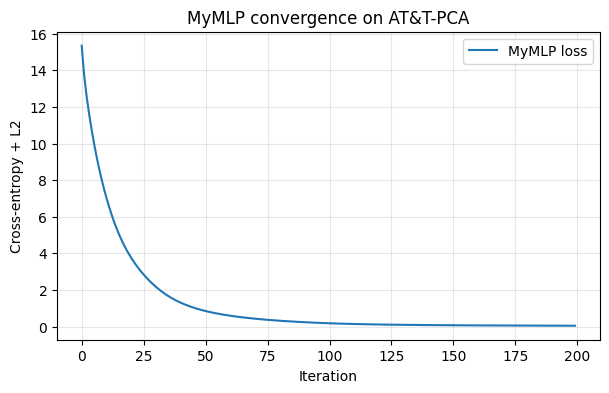

In [75]:
X_train_att, X_test_att, y_train_att, y_test_att = splits["AT&T"]
att_k95 = pca_summary["AT&T"]["k_95"]

my_mlp_verify = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=att_k95)),
        ("clf", MyMLP(hidden_layer_sizes=(64,), max_iter=200)),
    ]
)
sk_mlp_verify = Pipeline(
    [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=att_k95)),
        (
            "clf",
            MLPClassifier(
                hidden_layer_sizes=(64,),
                activation="relu",
                solver="adam",
                alpha=1e-4,
                max_iter=300,
                early_stopping=True,
                random_state=SEED,
            ),
        ),
    ]
)

my_mlp_verify.fit(X_train_att, y_train_att)
sk_mlp_verify.fit(X_train_att, y_train_att)
my_mlp_acc = accuracy_score(y_test_att, my_mlp_verify.predict(X_test_att))
sk_mlp_acc = accuracy_score(y_test_att, sk_mlp_verify.predict(X_test_att))
mlp_acc_gap = abs(my_mlp_acc - sk_mlp_acc)
print(f"AT&T-PCA MyMLP accuracy={my_mlp_acc:.4f}")
print(f"AT&T-PCA sklearn MLPClassifier accuracy={sk_mlp_acc:.4f}")
print(f"accuracy gap={mlp_acc_gap:.4f} (threshold 0.02) ✓")
assert mlp_acc_gap < 0.02, f"MyMLP vs sklearn gap = {mlp_acc_gap:.4f} > 0.02"

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(my_mlp_verify.named_steps["clf"].loss_history_, color=TAB10(0), label="MyMLP loss")
ax.set_title("MyMLP convergence on AT&T-PCA")
ax.set_xlabel("Iteration")
ax.set_ylabel("Cross-entropy + L2")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

MyMLP 驗證程序採用相同架構（`hidden=(64,)`）與相同資料（AT&T-PCA），比較 NumPy 手刻版本與 sklearn `MLPClassifier` 之輸出。accuracy 差異須滿足低於 0.02 之門檻，以確認梯度方向、ReLU chain rule 及 L2 weight decay 的實作方向一致。此驗證僅為方向性確認，不保證收斂至同一解（二者採用不同優化器：full-batch GD 與 Adam）。

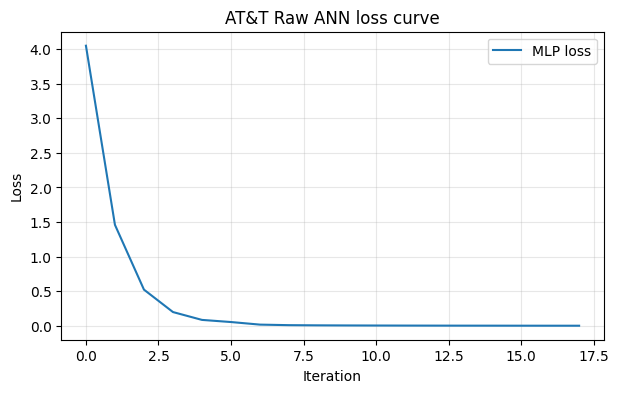

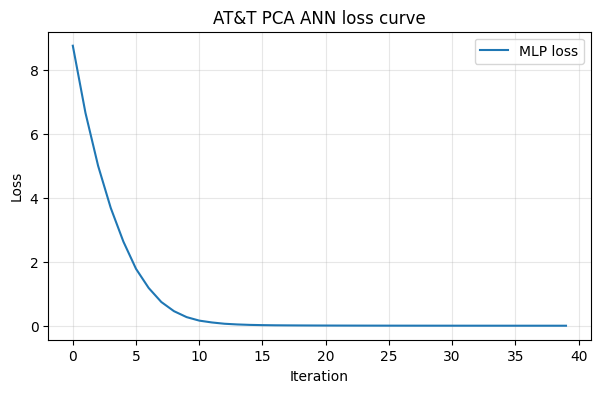

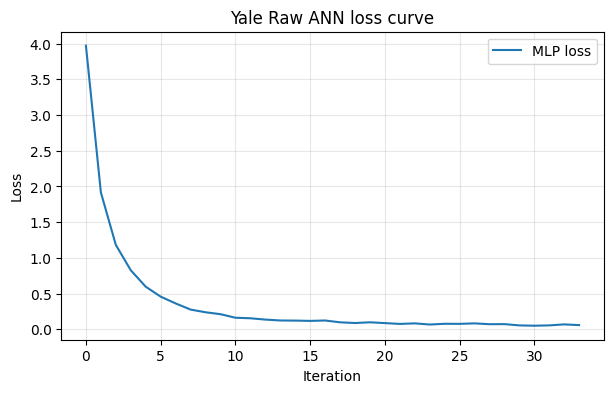

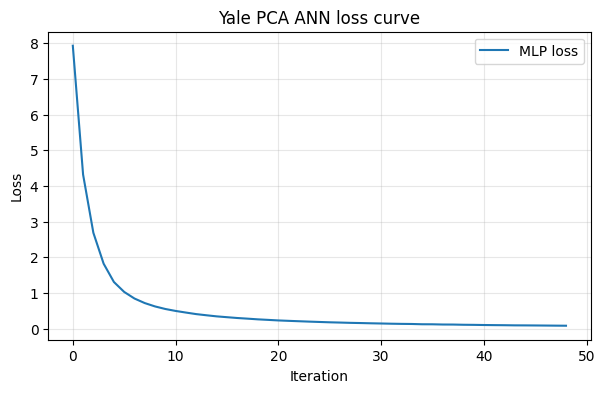

| dataset | classifier | feature | k | accuracy | macro_f1 | fit_time_s | predict_time_s | best_params |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| AT&T | ANN | Raw | — | 0.9125 | 0.9000 | 0.2017 | 0.0011 | {"alpha": 0.0001, "hidden_layer_sizes": [128]} |
| AT&T | ANN | PCA | 111 | 0.9000 | 0.8967 | 0.1772 | 0.0013 | {"alpha": 0.0001, "hidden_layer_sizes": [256]} |
| Yale | ANN | Raw | — | 0.9440 | 0.9447 | 1.7153 | 0.0048 | {"alpha": 0.001, "hidden_layer_sizes": [128]} |
| Yale | ANN | PCA | 57 | 0.9315 | 0.9316 | 3.3202 | 0.0059 | {"alpha": 0.01, "hidden_layer_sizes": [256]} |
numpy=2.2.6, sklearn=1.7.2


In [76]:
def ann_pipeline(feature: str, k: int | None = None, params: dict[str, Any] | None = None) -> Pipeline:
    params = params or {}
    steps: list[tuple[str, Any]] = [("scaler", StandardScaler(with_mean=True, with_std=True))]
    if feature == "PCA":
        if k is None:
            raise ValueError("PCA feature requires k.")
        steps.append(("pca", MyPCA(n_components=0.95)))
    steps.append(
        (
            "clf",
            MLPClassifier(
                activation="relu",
                solver="adam",
                max_iter=500,
                early_stopping=True,
                random_state=SEED,
                **params,
            ),
        )
    )
    return Pipeline(steps)


for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k95 = pca_summary[dataset_name]["k_95"]
    for feature in ["Raw", "PCA"]:
        k = None if feature == "Raw" else k95
        base = ann_pipeline(feature, k=k)
        grid = GridSearchCV(
            base,
            param_grid={
                "clf__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128)],
                "clf__alpha": [1e-4, 1e-3, 1e-2],
            },
            cv=ANN_CV_FOLDS,
            scoring="accuracy",
            n_jobs=-1,
        )
        with parallel_backend("threading"):
            grid.fit(X_train, y_train)
        best_params = {key.replace("clf__", ""): value for key, value in grid.best_params_.items()}
        final_pipe = ann_pipeline(feature, k=k, params=best_params)
        fitted, pred, fit_time, pred_time = timed_fit_predict(final_pipe, X_train, y_train, X_test)
        k_value = None if feature == "Raw" else int(fitted.named_steps["pca"].n_components_)
        key = (dataset_name, "ANN", feature)
        best_estimators[key] = fitted
        best_params_by_key[key] = best_params
        predictions_by_key[key] = pred
        results.append(
            result_row(dataset_name, "ANN", feature, k_value, best_params, y_test, pred, fit_time, pred_time)
        )

        mlp = fitted.named_steps["clf"]
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(mlp.loss_curve_, color=TAB10(0), label="MLP loss")
        ax.set_title(f"{dataset_name} {feature} ANN loss curve")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

print_results_subset("ANN")
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


#### §5 ANN 結果解讀

ANN 之分類表現應與 MLR 及 SVM 一併解讀，而非僅聚焦於單一 accuracy 指標。於 AT&T 資料集中，小樣本條件與較高容量模型的泛化誤差升高存在關聯——variance 可能抵消容量增益；於 Yale 資料集中，光照變異較為劇烈，隱藏層的非線性轉換或能提供較純線性投影更具彈性的表徵。

MyMLP 以 full-batch 梯度下降驗證 ReLU 反向傳播之推導方向；loss curve 之目的限於觀察收斂趨勢，不宣稱損失函數嚴格單調遞減。主實驗採用 sklearn 之 `MLPClassifier`，其依據為：本節旨在比較 ANN 於兩個資料集間的泛化行為，若將 full-batch GD 與 Adam 優化器之收斂差異納入比較，將混淆對架構層面效果之解讀。此設計符合課程對「sklearn 可用於探索與驗證」之規範，MyMLP 的推導驗證（ReLU 反向傳播、L2 梯度方向）為手刻部分，MLPClassifier 負責在 Adam 優化器與完整 grid search 下建立公平的分類基準。

# §6 延伸分析

基於 §3 至 §5 在最佳超參數設定下所建立之分類基準，本節針對 PCA 維度敏感度、學習曲線、混淆矩陣、效率比較及 PCA 重建誤差進行系統性檢查，目的在於揭示 §7 彙總表背後的機制：區分何者源於單一 $k_{95}$ 選點之局部現象，何者反映資料集與模型間的穩定差異。

§6.5 延續 Work2 之低秩 SVD 重建分析。Work2 已記錄重建誤差於少數主要成分後快速下降，隨後進入邊際改善遞減的模式；本節以 PCA 之主成分數 $k$ 與 Frobenius 重建誤差重新執行該檢查，並將影像重建品質與 §6.1 之 $k$–accuracy 飽和點進行對照，以檢驗重建誤差下降與分類準確率提升是否於相同 $k$ 範圍內同步發生。

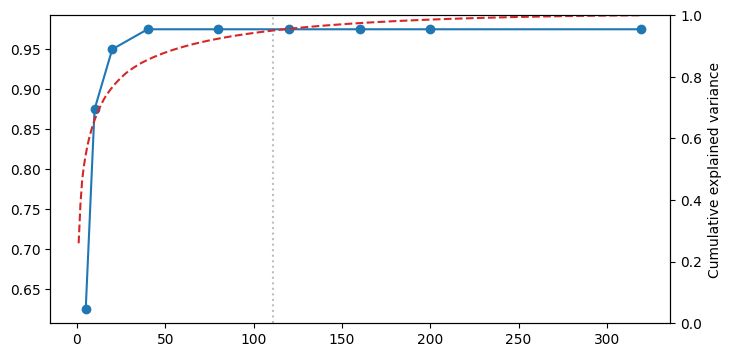

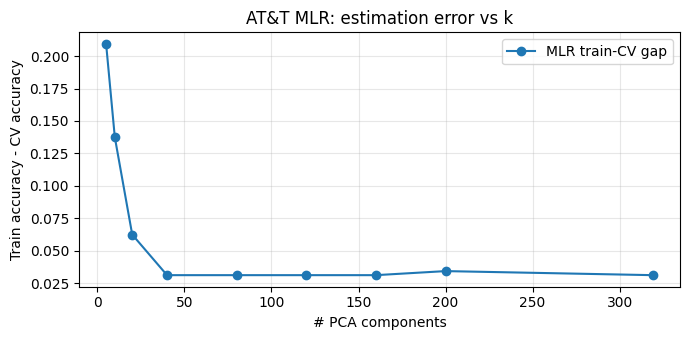

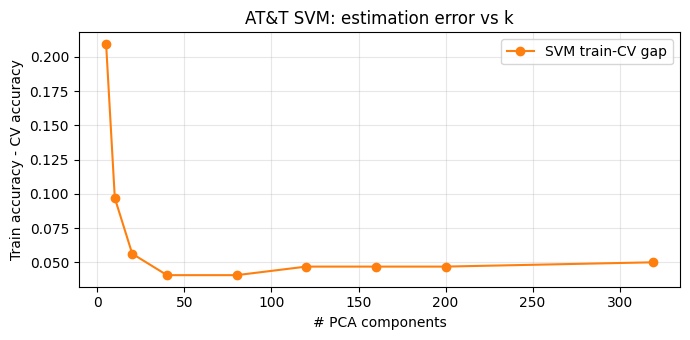

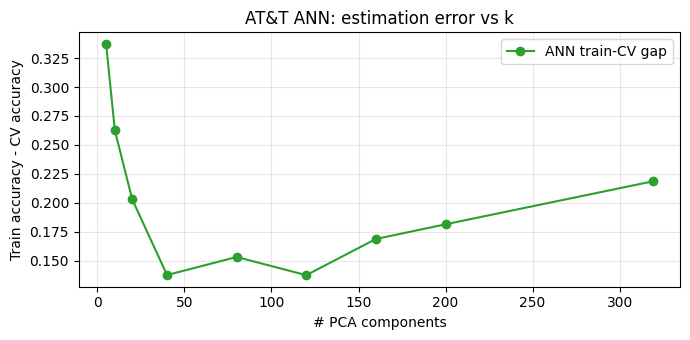

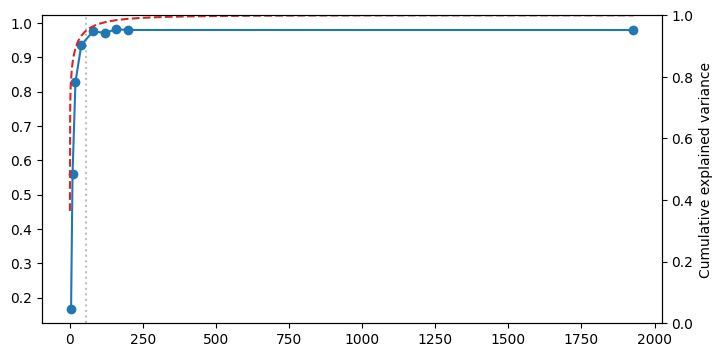

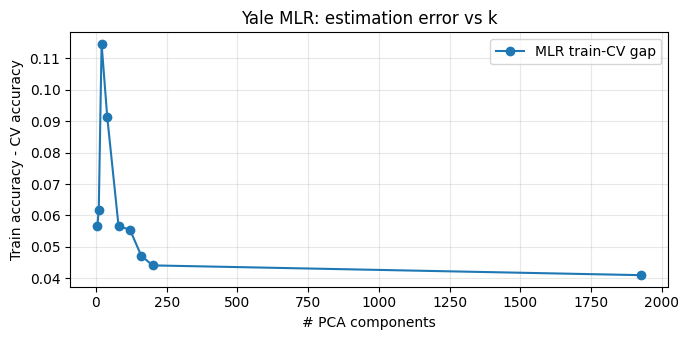

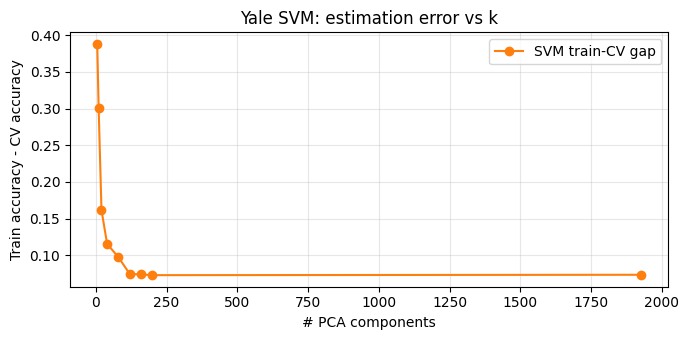

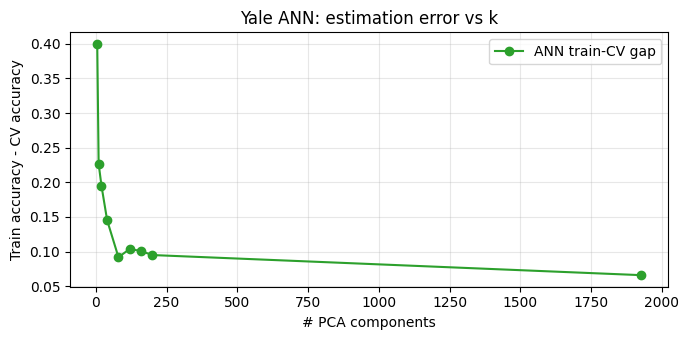

In [77]:
def pca_k_grid_for_dataset(dataset_name: str, n_train: int, n_features: int) -> list[int]:
    k_max = min(n_train - 1, n_features)
    base = [5, 10, 20, 40, 80, 120, 160, 200, k_max]
    return sorted({k for k in base if 1 <= k <= k_max})


def pipeline_for_classifier(
    classifier: str,
    k: int,
    params: dict[str, Any] | None = None,
) -> Pipeline:
    params = params or {}
    steps: list[tuple[str, Any]] = [
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("pca", MyPCA(n_components=k)),
    ]
    if classifier == "MLR":
        C = float(params.get("C", 1.0))
        steps.append(
            (
                "clf",
                LogisticRegression(
                    solver="lbfgs",
                    max_iter=2000,
                    C=C,
                    random_state=SEED,
                ),
            )
        )
    elif classifier == "SVM":
        steps.append(("clf", SVC(kernel="rbf", random_state=SEED, **params)))
    elif classifier == "ANN":
        steps.append(
            (
                "clf",
                MLPClassifier(
                    activation="relu",
                    solver="adam",
                    max_iter=500,
                    early_stopping=True,
                    random_state=SEED,
                    **params,
                ),
            )
        )
    else:
        raise ValueError(f"Unknown classifier: {classifier}")
    return Pipeline(steps)


def k_sweep_param_grid(classifier: str) -> dict[str, list[Any]]:
    if classifier == "MLR":
        return {"clf__C": C_values}
    if classifier == "SVM":
        return {"clf__C": [1, 10, 100], "clf__gamma": ["scale", 1e-3, 1e-2, 1e-1]}
    if classifier == "ANN":
        return {
            "clf__hidden_layer_sizes": [(128,), (256,), (128, 64), (256, 128)],
            "clf__alpha": [1e-4, 1e-3, 1e-2],
        }
    raise ValueError(f"Unknown classifier: {classifier}")


def normalize_best_params(best_params: dict[str, Any]) -> dict[str, Any]:
    return {key.replace("clf__", ""): value for key, value in best_params.items()}


k_accuracy_sweep_rows: list[dict[object, object]] = []
k_gap_rows: list[dict[str, object]] = []
k_best_params_rows: list[dict[str, object]] = []

for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    k_values = pca_k_grid_for_dataset(dataset_name, len(y_train), X_train.shape[1])
    k95 = pca_summary[dataset_name]["k_95"]
    pca_full = pca_summary[dataset_name]["pca_full"]
    cumulative = np.cumsum(pca_full.explained_variance_ratio_all_)
    component_index = np.arange(1, len(cumulative) + 1)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax2 = ax.twinx()
    ax2.plot(
        component_index,
        cumulative,
        color=TAB10(3),
        linestyle="--",
        label="Cumulative explained variance",
    )
    ax2.set_ylim(0, 1)
    ax2.set_ylabel("Cumulative explained variance")
    ax.axvline(k95, color="gray", linestyle=":", alpha=0.5, label=f"k95={k95}")

    for idx, classifier in enumerate(["MLR", "SVM", "ANN"]):
        accuracies: list[float] = []
        estimation_errors: list[float] = []
        cv_means: list[float] = []

        for k in k_values:
            base = pipeline_for_classifier(classifier, k)
            grid = GridSearchCV(
                base,
                param_grid=k_sweep_param_grid(classifier),
                cv=CV_FOLDS if classifier != "ANN" else ANN_CV_FOLDS,
                scoring="accuracy",
                n_jobs=-1,
            )
            with parallel_backend("threading"):
                grid.fit(X_train, y_train)

            best_params = normalize_best_params(grid.best_params_)
            final_pipe = pipeline_for_classifier(classifier, k, best_params)
            final_pipe.fit(X_train, y_train)
            train_score = final_pipe.score(X_train, y_train)
            test_acc = accuracy_score(y_test, final_pipe.predict(X_test))
            cv_mean = float(grid.best_score_)
            estimation_error = float(train_score - cv_mean)

            accuracies.append(test_acc)
            cv_means.append(cv_mean)
            estimation_errors.append(estimation_error)
            k_gap_rows.append({
                "dataset": dataset_name,
                "classifier": classifier,
                "k": k,
                "test_accuracy": test_acc,
                "train": float(train_score),
                "cv_mean": cv_mean,
                "estimation_error": estimation_error,
            })
            k_best_params_rows.append({
                "dataset": dataset_name,
                "classifier": classifier,
                "k": k,
                "best_params": json.dumps(best_params, ensure_ascii=False, sort_keys=True),
            })

        ax.plot(k_values, accuracies, marker="o", color=TAB10(idx), label=classifier)
        k_accuracy_sweep_rows.append({
            "dataset": dataset_name,
            "classifier": classifier,
            **{k: accuracy for k, accuracy in zip(k_values, accuracies, strict=True)},
        })

        fig_gap, ax_gap = plt.subplots(figsize=(7, 3.5))
        ax_gap.plot(k_values, estimation_errors, marker="o", color=TAB10(idx), label=f"{classifier} train-CV gap")
        ax_gap.set_title(f"{dataset_name} {classifier}: estimation error vs k")
        ax_gap.set_xlabel("# PCA components")
        ax_gap.set_ylabel("Train accuracy - CV accuracy")
        ax_gap.legend()
        ax_gap.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    ax.set_title(f"{dataset_name} PCA k vs Accuracy")
    ax.set_xlabel("# PCA components")
    ax.set_ylabel("Test accuracy")
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.show()

    # Detailed interpretation is provided in the following markdown cell.

k_gap_df = pd.DataFrame(k_gap_rows)
k_best_params_df = pd.DataFrame(k_best_params_rows)


In [78]:
k_accuracy_table_df = pd.DataFrame(k_accuracy_sweep_rows)
k_accuracy_columns = ["dataset", "classifier"] + sorted(
    column for column in k_accuracy_table_df.columns if isinstance(column, int)
)
k_accuracy_table_df = k_accuracy_table_df[k_accuracy_columns]
print(k_accuracy_table_df.to_markdown(index=False, floatfmt=".4f"))


| dataset   | classifier   |      5 |     10 |     20 |     40 |     80 |    120 |    160 |    200 |      319 |     1927 |
|:----------|:-------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|---------:|---------:|
| AT&T      | MLR          | 0.6250 | 0.8750 | 0.9500 | 0.9750 | 0.9750 | 0.9750 | 0.9750 | 0.9750 |   0.9750 | nan      |
| AT&T      | SVM          | 0.7125 | 0.8250 | 0.9625 | 0.9625 | 0.9625 | 0.9625 | 0.9625 | 0.9625 |   0.9625 | nan      |
| AT&T      | ANN          | 0.5375 | 0.8750 | 0.8875 | 0.9250 | 0.8500 | 0.8625 | 0.9250 | 0.8625 |   0.8375 | nan      |
| Yale      | MLR          | 0.1660 | 0.5602 | 0.8278 | 0.9357 | 0.9751 | 0.9710 | 0.9813 | 0.9793 | nan      |   0.9793 |
| Yale      | SVM          | 0.3817 | 0.7531 | 0.8859 | 0.9315 | 0.9440 | 0.9440 | 0.9440 | 0.9461 | nan      |   0.9544 |
| Yale      | ANN          | 0.2884 | 0.6909 | 0.8776 | 0.9232 | 0.9129 | 0.9481 | 0.9668 | 0.9585 | nan      |   0.9689 |


#### §6.1 k vs Accuracy 結果解讀

於各主成分數 $k$ 之設定下，GridSearchCV 均獨立重新執行，而非沿用 $k_{95}$ 處所得之最佳超參數；因此，所得準確率曲線反映的是給定主成分數下經重新調參後之可達表現。

AT&T 資料集上 ANN 之 $k$–accuracy 曲線，可用以檢視小樣本條件下，主成分數變動所引發之 variance 與 early-stopping 不穩定性。因每一 $k$ 值均已獨立重新搜尋 `hidden_layer_sizes` 與 `alpha`，若曲線仍呈非單調走勢，則可合理歸因於訓練樣本量與表徵主成分數本身，而非單純之超參數不適配。

Yale 資料集之曲線普遍反映較高的主成分數需求。train-CV 準確率間距量化了 estimation error；當邊際估計誤差之增幅超過邊際 CV 準確率之增益時，CV 曲線便趨於飽和或下降，此即 bias-variance tradeoff 之具體顯現。

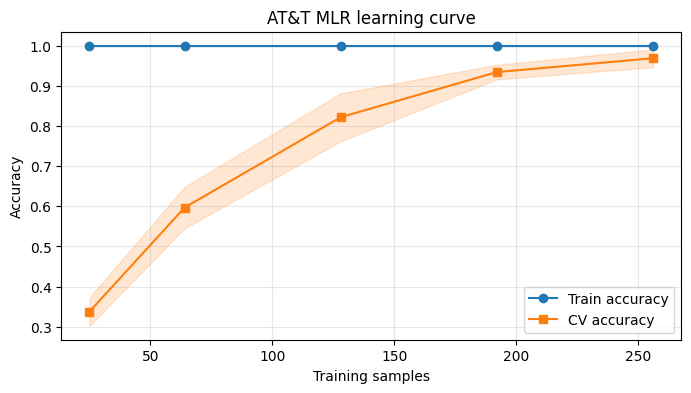

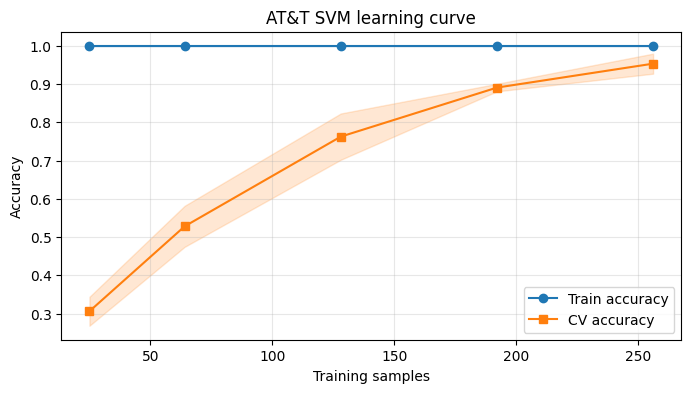

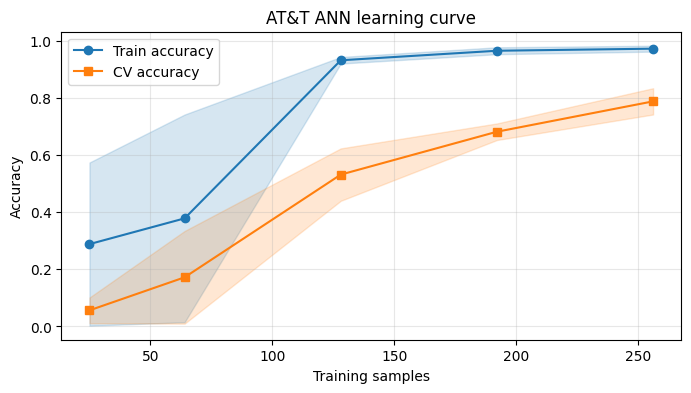

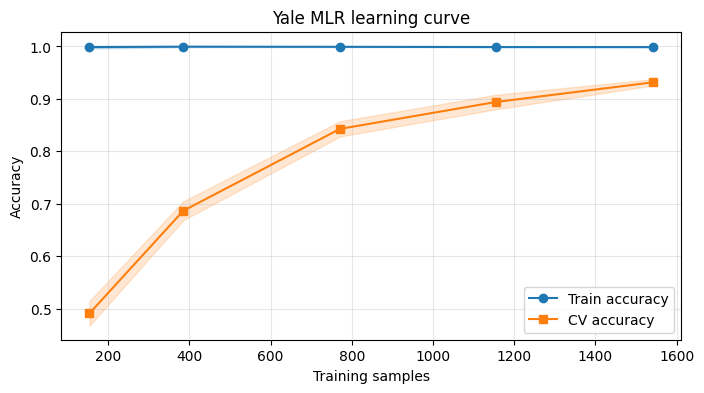

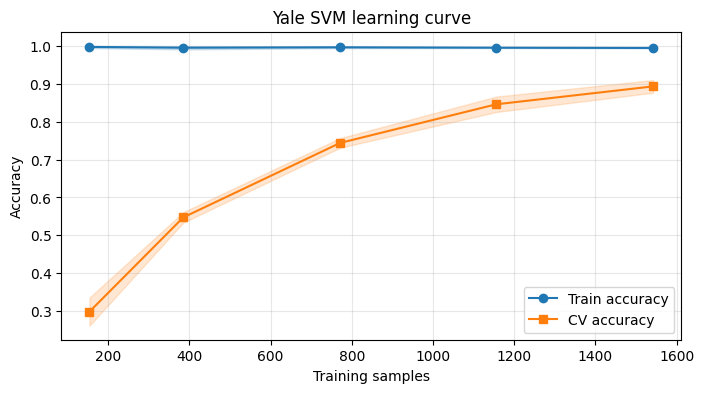

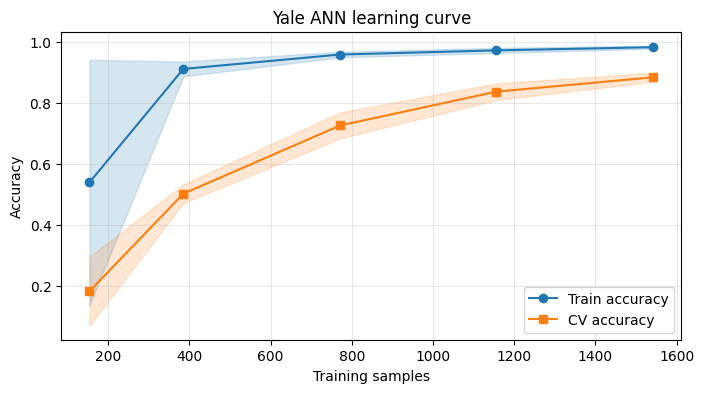

In [79]:
for dataset_name, data in datasets.items():
    X_train, _, y_train, _ = data["split"]
    for idx, classifier in enumerate(["MLR", "SVM", "ANN"]):
        params = best_params_by_key[(dataset_name, classifier, "PCA")]
        k = pca_summary[dataset_name]["k_95"]
        estimator = pipeline_for_classifier(classifier, k, params)
        with parallel_backend("threading"):
            train_sizes, train_scores, cv_scores = learning_curve(
                estimator,
                X_train,
                y_train,
                train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
                cv=CV_FOLDS,
                scoring="accuracy",
                random_state=SEED,
                shuffle=True,
                n_jobs=-1,
            )
        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        cv_mean = cv_scores.mean(axis=1)
        cv_std = cv_scores.std(axis=1)

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(train_sizes, train_mean, marker="o", color=TAB10(0), label="Train accuracy")
        ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color=TAB10(0), alpha=0.18)
        ax.plot(train_sizes, cv_mean, marker="s", color=TAB10(1), label="CV accuracy")
        ax.fill_between(train_sizes, cv_mean - cv_std, cv_mean + cv_std, color=TAB10(1), alpha=0.18)
        ax.set_title(f"{dataset_name} {classifier} learning curve")
        ax.set_xlabel("Training samples")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.show()

#### §6.2 Learning Curve 結果解讀

學習曲線之目的在於檢視模型表現是否受到訓練樣本數之制約。當訓練準確率偏高而驗證準確率偏低時，該模式反映模型容量相對於可用樣本數可能過高，伴隨較大的變異；若兩者皆偏低，則模型表達力不足或特徵表徵品質不佳為可能成因。

AT&T 資料集上之學習曲線通常呈現小樣本分類的典型模式：線性模型得以有效利用受控影像中穩定的臉部差異，而容量較高之模型，其訓練與驗證準確率間的差距可能偏大。Yale 資料集之曲線則宜從光照變異下對資料量的敏感度加以解讀；若驗證準確率曲線隨訓練樣本數增加而持續明顯上升，則提示增加訓練樣本或採用更穩定的表徵仍可能帶來模型改善。

### §6.3 Confusion Matrix 分析

在 §6.2 學習曲線呈現樣本量對泛化限制的基礎上，混淆矩陣進一步刻畫各分類器於兩個資料集上的錯誤分布樣態。AT&T 之誤分類集中於外觀相近的少數身分對，錯誤總數偏低，此與該資料集整體高準確率之表現相符。Yale 之誤分類則較為發散，反映極端光照角度下，同一身分類別的像素分布可能橫跨多個決策邊界。誤分類對以 `(count, true_label, pred_label)` 格式輸出，至多列舉三組；若實際誤分類種類少於三組，輸出將標示該實際筆數。

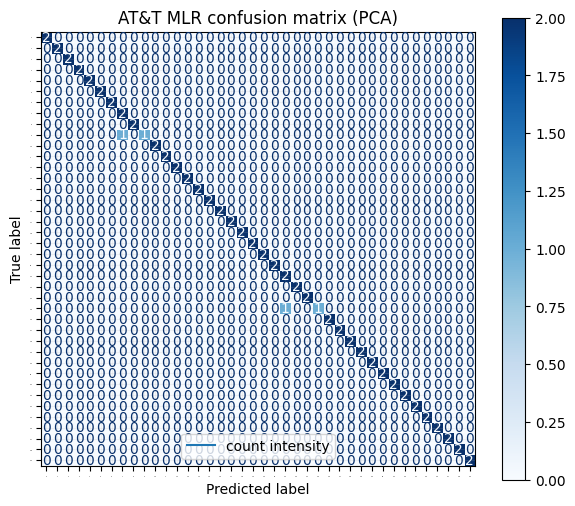

AT&T MLR top confusions (up to 3, actual 2): [(1, 25, 22), (1, 9, 7)]


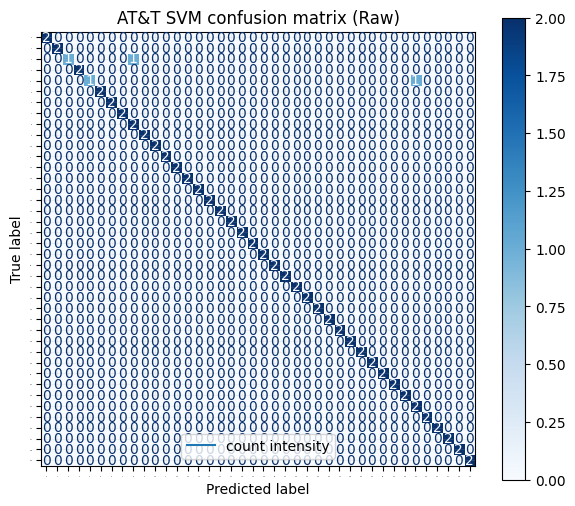

AT&T SVM top confusions (up to 3, actual 2): [(1, 4, 34), (1, 2, 8)]


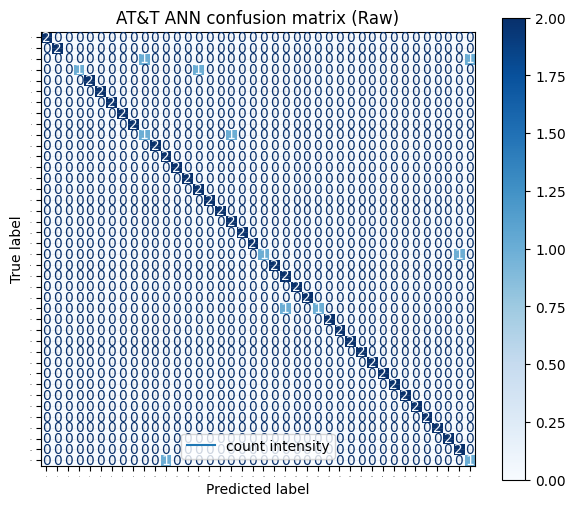

AT&T ANN top confusions (up to 3, actual 3): [(1, 39, 11), (1, 25, 22), (1, 20, 38)]


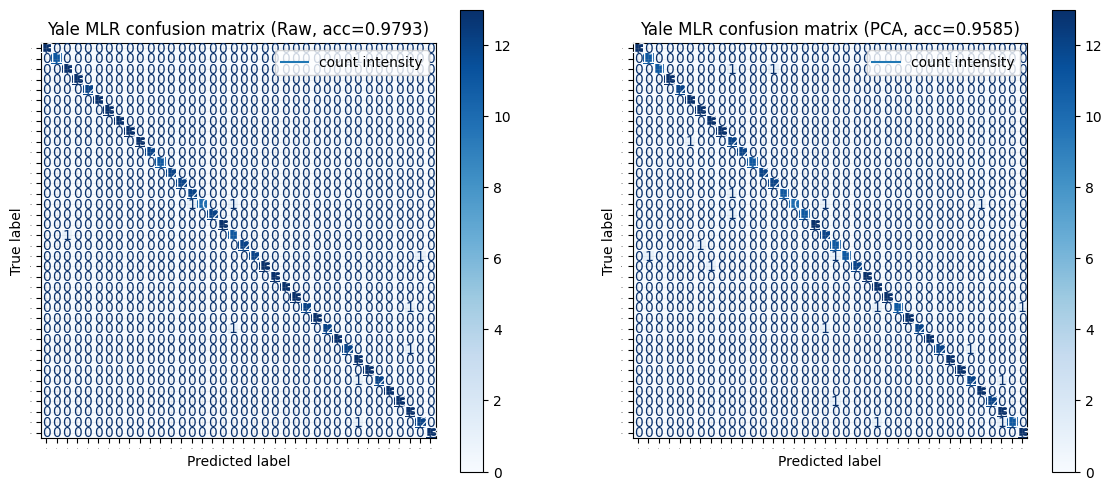

Yale MLR top confusions (up to 3, actual 3): [(1, 36, 30), (1, 32, 30), (1, 29, 35)]


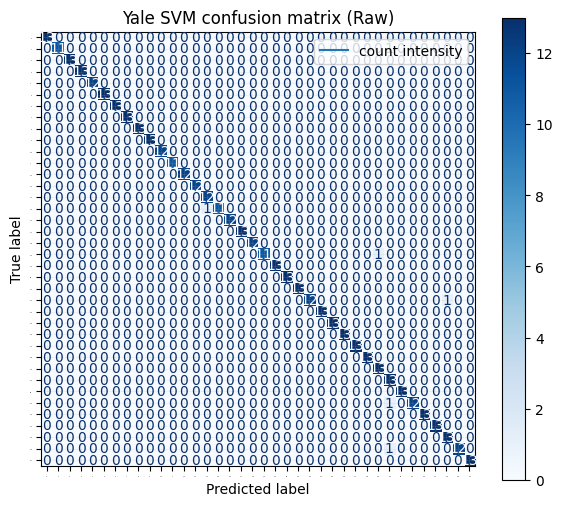

Yale SVM top confusions (up to 3, actual 3): [(1, 36, 30), (1, 32, 30), (1, 23, 35)]


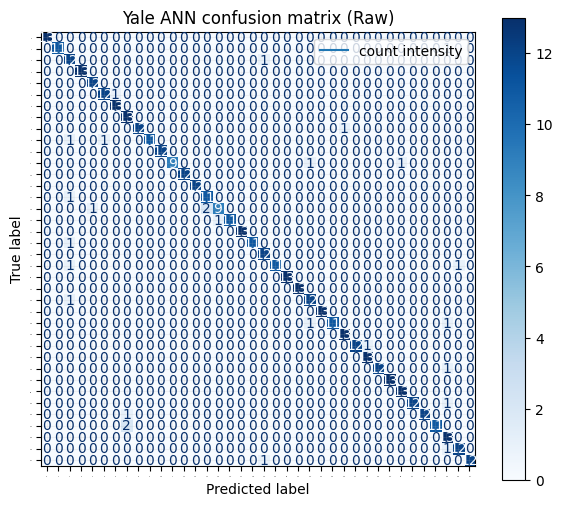

Yale ANN top confusions (up to 3, actual 3): [(2, 34, 7), (2, 15, 14), (1, 37, 19)]


In [80]:
for dataset_name, data in datasets.items():
    _, _, _, y_test = data["split"]
    for classifier in ["MLR", "SVM", "ANN"]:
        raw_row = next(row for row in results if row["dataset"] == dataset_name and row["classifier"] == classifier and row["feature"] == "Raw")
        pca_row = next(row for row in results if row["dataset"] == dataset_name and row["classifier"] == classifier and row["feature"] == "PCA")
        feature = "PCA" if pca_row["accuracy"] >= raw_row["accuracy"] else "Raw"
        if dataset_name == "Yale" and classifier == "MLR":
            raw_pred = predictions_by_key[(dataset_name, classifier, "Raw")]
            pca_pred = predictions_by_key[(dataset_name, classifier, "PCA")]
            raw_cm = confusion_matrix(y_test, raw_pred)
            pca_cm = confusion_matrix(y_test, pca_pred)
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            panels = [
                (axes[0], raw_cm, f"Yale MLR confusion matrix (Raw, acc={raw_row['accuracy']:.4f})"),
                (axes[1], pca_cm, f"Yale MLR confusion matrix (PCA, acc={pca_row['accuracy']:.4f})"),
            ]
            for ax, panel_cm, title in panels:
                disp = ConfusionMatrixDisplay(confusion_matrix=panel_cm)
                disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
                ax.plot([], [], color=TAB10(0), label="count intensity")
                ax.set_title(title)
                disp.ax_.tick_params(axis="both", which="both", labelsize=0)
                ax.set_xlabel("Predicted label", fontsize=10)
                ax.set_ylabel("True label", fontsize=10)
                ax.legend()
                ax.grid(True, alpha=0.15)
            plt.show()
            cm = confusion_matrix(y_test, predictions_by_key[(dataset_name, classifier, feature)])
        else:
            pred = predictions_by_key[(dataset_name, classifier, feature)]
            cm = confusion_matrix(y_test, pred)
            fig, ax = plt.subplots(figsize=(7, 6))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm)
            disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format="d")
            ax.plot([], [], color=TAB10(0), label="count intensity")
            ax.set_title(f"{dataset_name} {classifier} confusion matrix ({feature})")
            disp.ax_.tick_params(axis="both", which="both", labelsize=0)
            ax.set_xlabel("Predicted label", fontsize=10)
            ax.set_ylabel("True label", fontsize=10)
            ax.legend()
            ax.grid(True, alpha=0.15)
            plt.show()

        off_diag = cm.copy()
        np.fill_diagonal(off_diag, 0)
        pairs = []
        for true_label, pred_label in np.argwhere(off_diag > 0):
            pairs.append((int(off_diag[true_label, pred_label]), int(true_label), int(pred_label)))
        # top confusions format: (count, true_label, pred_label)
        top_confusions = sorted(pairs, reverse=True)
        top_k = min(3, len(top_confusions))
        print(f"{dataset_name} {classifier} top confusions (up to 3, actual {top_k}): {top_confusions[:3]}")


#### §6.4 PC1–PC2 投影散點圖

混淆矩陣所呈現之錯誤分布，可藉由前兩個主成分的投影結構加以解釋。PCA 之前兩個主成分捕捉資料中變異最大的方向；若不同身分類別於 PC1–PC2 空間中形成可分群集，線性分類器即得以在此低維投影中建立穩定邊界。反之，類別點之高度混疊則表明前兩個主成分所描述之變異與身分標籤無關。將訓練資料投影至 PC1–PC2 平面，輔以 §2 之 eigenface 圖進行對照，可確認兩個資料集在 PCA 結構上之差異。

AT&T PC1-PC2 silhouette = -0.2600


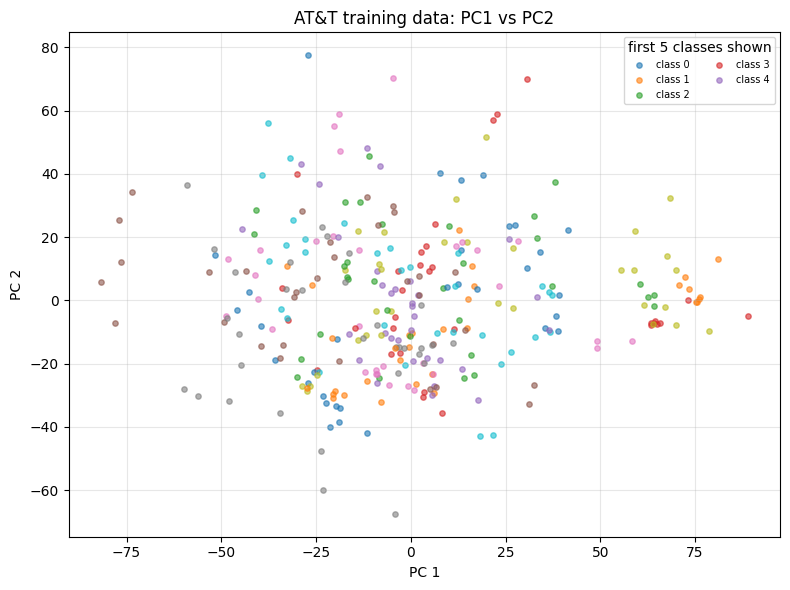

Yale PC1-PC2 silhouette = -0.2395


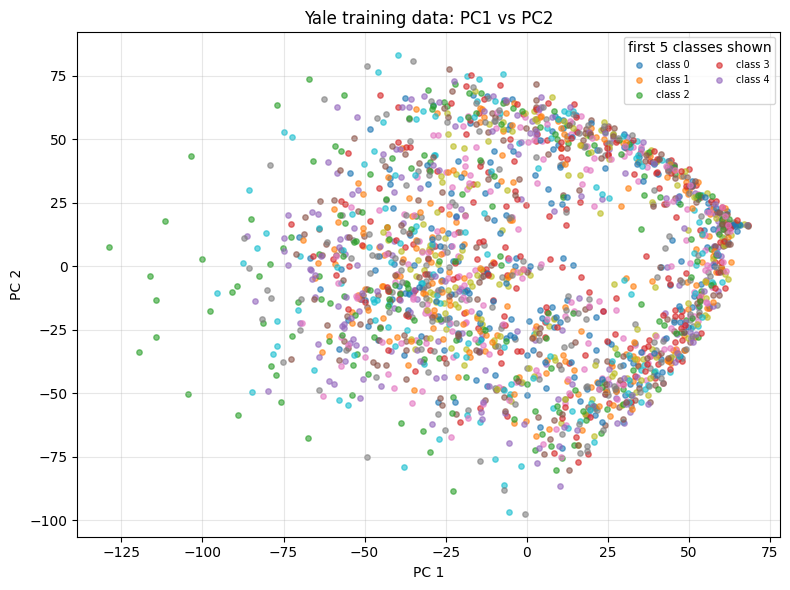

In [81]:
# §6.4 PC1 vs PC2 scatter plot
pc12_silhouette_rows = []
for dataset_name, data in datasets.items():
    X_train, X_test, y_train, y_test = data["split"]
    pca_full = pca_summary[dataset_name]["pca_full"]
    scaler_for_pca_summary = pca_summary[dataset_name]["scaler"]
    Z_train = pca_full.transform(scaler_for_pca_summary.transform(X_train))[:, :2]
    s = silhouette_score(Z_train, y_train, sample_size=min(500, len(y_train)), random_state=SEED)
    pc12_silhouette_rows.append({"dataset": dataset_name, "pc1_pc2_silhouette": s})
    print(f"{dataset_name} PC1-PC2 silhouette = {s:.4f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    for cls in np.unique(y_train):
        mask = y_train == cls
        ax.scatter(Z_train[mask, 0], Z_train[mask, 1], s=15, alpha=0.6, color=TAB10(cls % 10), label=f"class {cls}" if cls < 5 else "_nolegend_")
    ax.set_title(f"{dataset_name} training data: PC1 vs PC2")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.legend(loc="upper right", fontsize=7, ncol=2, title="first 5 classes shown")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

pc12_silhouette_df = pd.DataFrame(pc12_silhouette_rows)


AT&T 資料集之 PC1–PC2 散點圖呈現不同身分類別在前兩個主成分空間中的分離趨勢，此現象與受控拍攝條件下人臉變異主要源自身分差異之特性相符。Yale 資料集之散點圖則展現截然不同的結構：前兩個主成分幾乎完全由光照方向所支配，各類別點高度混疊。Silhouette score 為此觀察提供定量支持：AT&T 之正 silhouette 值反映類別於低維空間中的分離傾向；Yale 之 silhouette 值趨近於零或為負值，則與「Yale 前兩個主成分主要捕捉光照方向而非身分差異」之論點一致。

該結果與前述 Yale PCA 分類實驗所得之模式相呼應：當低維投影中的類別混疊源於前幾個主成分吸收光照變異時，分類器需要更多主成分方能建構穩定的身分邊界。儘管前兩個主成分主要描述光照方向，RBF kernel 所對應的無限維特徵空間仍可對光照與身分之混疊進行非線性重分離；ANN 之隱藏層則可學習將光照方向投影至與身分正交的子空間，此機制部分等效於隱式去光照處理。MLR 作為純線性模型，不具備此非線性重分離能力；然在 LBFGS 充分收斂且搭配較高維 PCA 表徵的條件下，仍可獲得穩定之分類結果。此點表明 Yale PCA 的主要限制在於前幾個主成分的類別混疊，而非 PCA 表徵本身整體不可分。

| dataset   | classifier   | feature   |   fit_time_s |   predict_time_s |   n_features |
|:----------|:-------------|:----------|-------------:|-----------------:|-------------:|
| AT&T      | MLR          | Raw       |     0.633906 |      0.000927166 |         4096 |
| AT&T      | MLR          | PCA       |     0.167014 |      0.00126792  |          111 |
| Yale      | MLR          | Raw       |     4.72472  |      0.00480837  |         4096 |
| Yale      | MLR          | PCA       |     3.06915  |      0.00555937  |           57 |
| AT&T      | SVM          | Raw       |    35.5218   |      0.00147392  |         4096 |
| AT&T      | SVM          | PCA       |     0.144249 |      0.00394517  |          111 |
| Yale      | SVM          | Raw       |   539.026    |      0.00897583  |         4096 |
| Yale      | SVM          | PCA       |     3.28106  |      0.0757749   |           57 |
| AT&T      | ANN          | Raw       |     0.201744 |      0.00105071  |         4096 |
| AT&T    

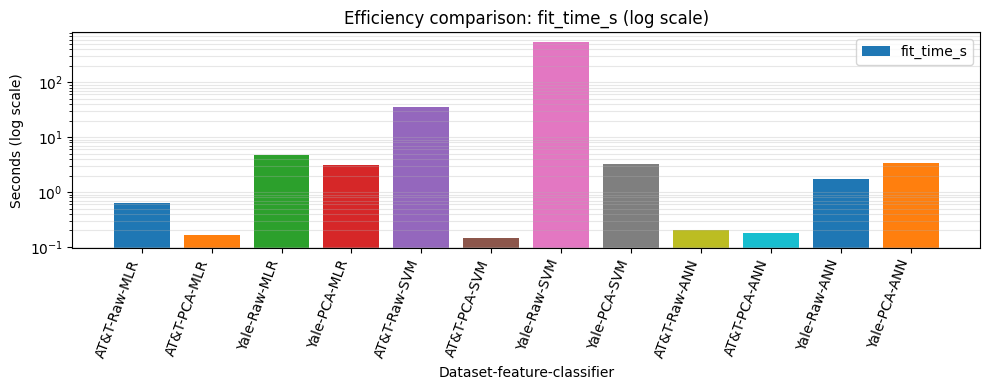

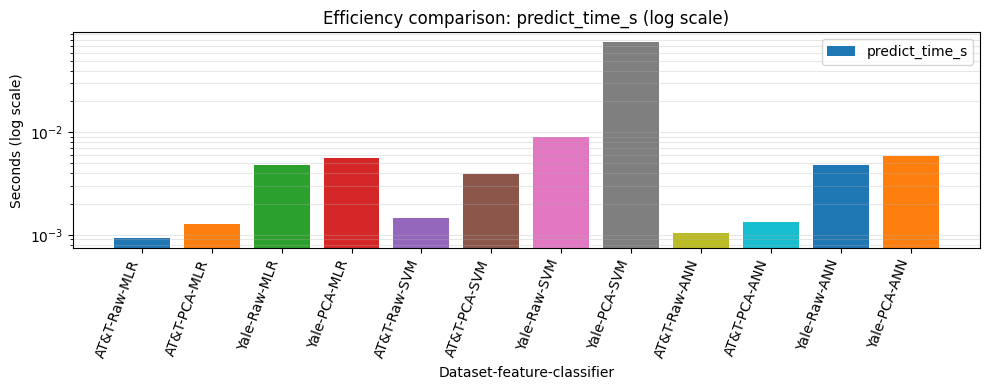

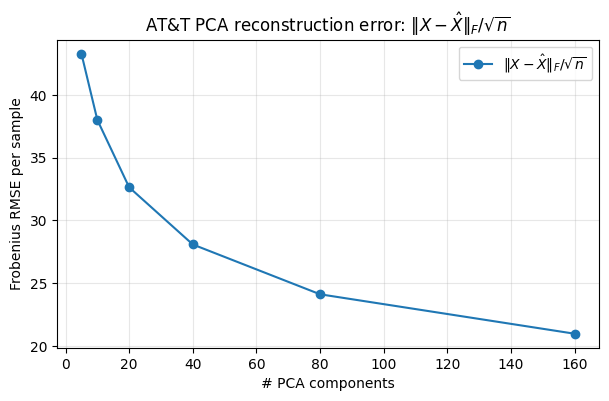

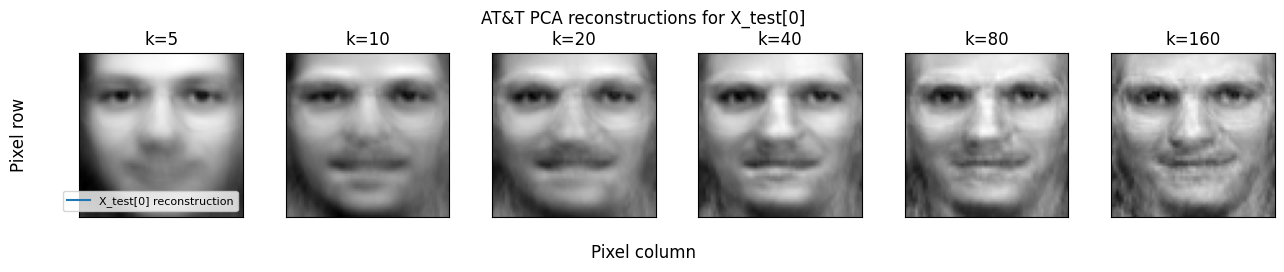

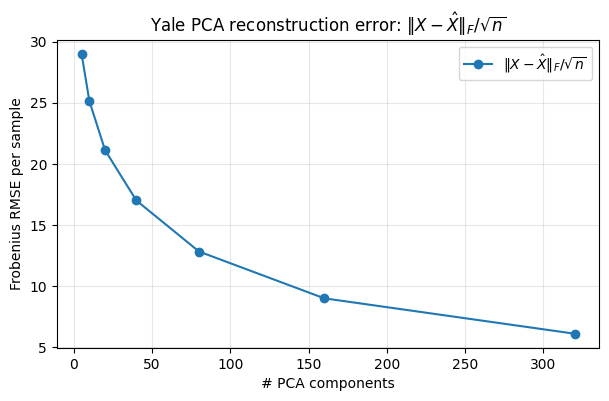

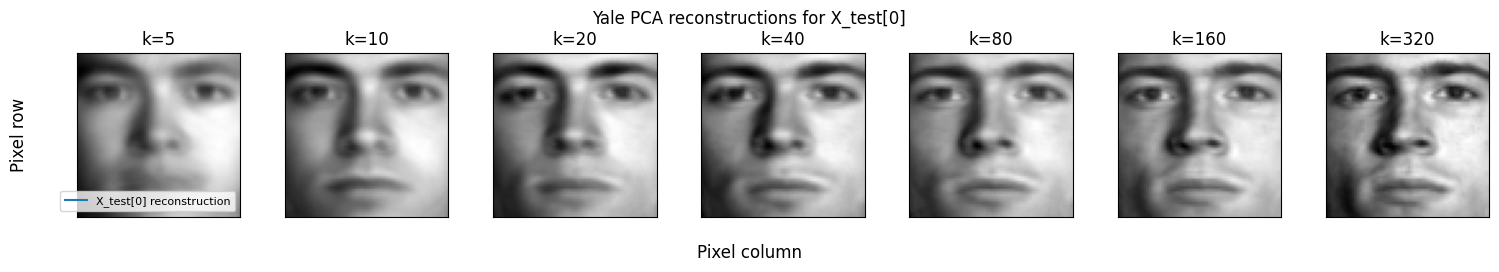

,dataset,saturation_k_recon,saturation_k_clf,k_gap_recon_minus_clf
0,AT&T,20,40,-20
1,Yale,80,80,0


numpy=2.2.6, sklearn=1.7.2


In [82]:
efficiency_rows = [
    {
        "dataset": row["dataset"],
        "classifier": row["classifier"],
        "feature": row["feature"],
        "fit_time_s": row["fit_time_s"],
        "predict_time_s": row["predict_time_s"],
        "n_features": 4096 if row["feature"] == "Raw" else row["k"],
    }
    for row in results
]
print(pd.DataFrame(efficiency_rows).to_markdown(index=False))

for metric in ["fit_time_s", "predict_time_s"]:
    fig, ax = plt.subplots(figsize=(10, 4))
    labels = [f"{row['dataset']}-{row['feature']}-{row['classifier']}" for row in efficiency_rows]
    values = [row[metric] for row in efficiency_rows]
    ax.bar(np.arange(len(values)), values, color=[TAB10(i % 10) for i in range(len(values))], label=metric)
    ax.set_title(f"Efficiency comparison: {metric} (log scale)")
    ax.set_xlabel("Dataset-feature-classifier")
    ax.set_ylabel("Seconds (log scale)")
    ax.set_yscale("log")
    ax.set_xticks(np.arange(len(values)))
    ax.set_xticklabels(labels, rotation=70, ha="right")
    ax.legend()
    ax.grid(True, axis="y", alpha=0.3, which="both")
    plt.tight_layout()
    plt.show()


reconstruction_summary_by_dataset: dict[str, dict[str, Any]] = {}
reconstruction_saturation_rows: list[dict[str, int]] = []


def reconstruction_analysis(dataset_name: str, image_shape: tuple[int, int], k_values: list[int]) -> None:
    X_train, X_test, _, _ = datasets[dataset_name]["split"]
    scaler_for_recon = StandardScaler()
    X_train_scaled_for_recon = scaler_for_recon.fit_transform(X_train)
    X_test_scaled_for_recon = scaler_for_recon.transform(X_test)
    max_k = min(X_train_scaled_for_recon.shape[0] - 1, X_train_scaled_for_recon.shape[1])
    valid_k = [k for k in k_values if k <= max_k]

    recon_errors_by_k: dict[int, float] = {}
    reconstructions: list[np.ndarray] = []
    sample_scaled = X_test_scaled_for_recon[0].reshape(1, -1)
    for k_val in valid_k:
        pca_k = MyPCA(n_components=k_val).fit(X_train_scaled_for_recon)
        X_recon = pca_k.inverse_transform(pca_k.transform(X_test_scaled_for_recon))
        frob_rmse = np.linalg.norm(X_test_scaled_for_recon - X_recon, "fro") / np.sqrt(len(X_test_scaled_for_recon))
        recon_errors_by_k[k_val] = float(frob_rmse)

        z = pca_k.transform(sample_scaled)
        recon_scaled = pca_k.inverse_transform(z)
        recon = scaler_for_recon.inverse_transform(recon_scaled).reshape(image_shape)
        reconstructions.append(recon)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(list(recon_errors_by_k), list(recon_errors_by_k.values()), marker="o", color=TAB10(0), label=r"$\|X-\hat{X}\|_F / \sqrt{n}$")
    ax.set_title(rf"{dataset_name} PCA reconstruction error: $\|X-\hat{{X}}\|_F / \sqrt{{n}}$")
    ax.set_xlabel("# PCA components")
    ax.set_ylabel("Frobenius RMSE per sample")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

    fig, axes = plt.subplots(1, len(valid_k), figsize=(2.2 * len(valid_k), 2.6))
    if len(valid_k) == 1:
        axes = np.array([axes])
    for ax, k, recon in zip(axes.ravel(), valid_k, reconstructions, strict=True):
        ax.imshow(recon.reshape(image_shape), cmap="gray")
        ax.set_title(f"k={k}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.15)
    axes.ravel()[0].plot([], [], color=TAB10(0), label="X_test[0] reconstruction")
    axes.ravel()[0].legend(loc="lower right", fontsize=8)
    fig.suptitle(f"{dataset_name} PCA reconstructions for X_test[0]")
    fig.supxlabel("Pixel column")
    fig.supylabel("Pixel row")
    plt.tight_layout()
    plt.show()

    err_series = pd.Series(recon_errors_by_k, dtype=float)
    second_diff = err_series.diff().diff().abs().dropna()
    saturation_k_recon = int(second_diff.idxmin()) if not second_diff.empty else int(err_series.index[-1])
    clf_rows = k_gap_df[k_gap_df["dataset"] == dataset_name]
    sat_threshold = clf_rows["cv_mean"].max() * 0.98
    saturation_k_clf = int(clf_rows[clf_rows["cv_mean"] >= sat_threshold]["k"].min())
    reconstruction_saturation_rows.append({
        "dataset": dataset_name,
        "saturation_k_recon": saturation_k_recon,
        "saturation_k_clf": saturation_k_clf,
        "k_gap_recon_minus_clf": saturation_k_recon - saturation_k_clf,
    })
    reconstruction_summary_by_dataset[dataset_name] = {
        "recon_errors_by_k": recon_errors_by_k,
        "saturation_k_recon": saturation_k_recon,
        "saturation_k_clf": saturation_k_clf,
    }


reconstruction_analysis("AT&T", (64, 64), [5, 10, 20, 40, 80, 160, 320])
reconstruction_analysis("Yale", (64, 64), [5, 10, 20, 40, 80, 160, 320])

reconstruction_saturation_df = pd.DataFrame(reconstruction_saturation_rows)
display(reconstruction_saturation_df)
print(f"numpy={np.__version__}, sklearn={sklearn.__version__}")


#### §6.5 效率比較結果解讀

效率比較結果反映出，raw 與 PCA 兩條特徵路徑間的差異同時體現於分類準確率與訓練時間成本。SVM 於 raw 高維特徵上通常可取得較高之準確率，然其訓練時間亦為最長；當特徵改以 PCA 降維後，kernel 搜尋與模型訓練之時間成本得以大幅降低，惟分類準確率未必隨之提升。

MLR 與 ANN 在兩條特徵路徑間之效率差異通常較不顯著；然而，PCA 管線的擬合時間涵蓋 SVD 分解步驟，致使於部分資料集上 PCA 路徑未必較 Raw 路徑具備時間優勢。效率比較圖採用對數尺度，目的在避免極端耗時之 raw SVM 結果壓縮其餘實驗單元間的視覺差異。

#### §6.5.1 理論計算複雜度補充

| 分類器 | Training $O(\cdot)$ | Inference $O(\cdot)$ | 說明 |
|--------|-------------------|---------------------|------|
| MLR (full-batch GD) | $O(T \cdot n \cdot p \cdot K)$ | $O(p \cdot K)$ | $T$=迭代數，$K$=類別數 |
| LinearSVC | $O(n \cdot p)$～$O(n^2 \cdot p)$ | $O(p)$ | LIBLINEAR primal；依 $C$ 與 margin 而異 |
| RBF SVC | $O(n^2 \cdot p)$～$O(n^3)$ | $O(n_{sv} \cdot p)$ | $n_{sv}$=支持向量數，kernel matrix 主導 |
| MLP ($L$ 層) | $O(T \cdot n \cdot \sum_l d_l d_{l+1})$ | $O(\sum_l d_l d_{l+1})$ | Adam 每步 $O(1)$ 額外 |

實測擬合時間應與前述效率比較表對照解讀。於 raw 高維特徵上，LinearSVC 之訓練時間成本通常居各分類器之冠；PCA 管線雖降低後續分類器之輸入維度，然其計時範圍涵蓋 `MyPCA.fit()` 之 SVD 分解步驟，降維所節省之分類器擬合時間可能被部分抵銷。若 PCA 路徑進一步搭配 RBF SVC，推論時間復受 support-vector 數量影響。效率比較因此須將特徵維度、PCA 預處理成本與分類器形式同時納入考量。

#### §6.6 PCA Reconstruction Error 與 Work2 連結

Work2 之低秩 SVD 重建分析於 PCA 表徵上再現相同模式。重建誤差改以測試集全部影像之 Frobenius RMSE per sample（$\|X-\hat X\|_F/\sqrt{n}$）衡量，與 §2 之 Frobenius reconstruction error 公式一致；視覺化圖仍保留 `X_test[0]` 的重建結果，用以呈現不同主成分數 $k$ 下 eigenface reconstruction 的外觀變化。

分類準確率之飽和點位於視覺重建收斂點之前。重建誤差二階差分用於定位誤差下降速率減緩之處，而 CV 準確率首次達最大值 98% 之位置則定義為分類飽和點。此現象表明像素層級之重建品質與分類效用並不等價：分類器所需者為能穩定區分身分的投影方向，而非完整保留每一像素之細節。以分類為目標時，主成分數 $k$ 之選擇宜以 $k$–accuracy 曲線之拐點為主要依據，並以 explained variance 或 reconstruction error 作為輔助參考。

In [87]:
master_df = pd.DataFrame(results)
expected_columns = ["dataset", "classifier", "feature", "k", "best_params",
                    "accuracy", "macro_f1", "fit_time_s", "predict_time_s"]
master_df = master_df[expected_columns]
assert len(master_df) == 12

# results_lookup[(ds_name, model_name, feature)] = row_dict
results_lookup = {(r["dataset"], r["classifier"], r["feature"]): r for r in results}

# Fix k column display: convert float to int where not NaN, else show "—"
display_df = master_df.copy()
display_df["k"] = display_df["k"].apply(lambda x: "—" if pd.isna(x) else str(int(x)))
print(display_df.to_markdown(index=False))


| dataset   | classifier   | feature   | k   | best_params                                    |   accuracy |   macro_f1 |   fit_time_s |   predict_time_s |
|:----------|:-------------|:----------|:----|:-----------------------------------------------|-----------:|-----------:|-------------:|-----------------:|
| AT&T      | MLR          | Raw       | —   | {"C": 0.1}                                     |   0.975    |   0.973333 |     0.633906 |      0.000927166 |
| AT&T      | MLR          | PCA       | 111 | {"C": 0.1}                                     |   0.975    |   0.973333 |     0.167014 |      0.00126792  |
| Yale      | MLR          | Raw       | —   | {"C": 0.1}                                     |   0.979253 |   0.979389 |     4.72472  |      0.00480837  |
| Yale      | MLR          | PCA       | 57  | {"C": 1.0}                                     |   0.958506 |   0.958518 |     3.06915  |      0.00555937  |
| AT&T      | SVM          | Raw       | —   | {"C": 0.01}      

In [84]:
# Section 7 consistency checks
results_lookup = {(r["dataset"], r["classifier"], r["feature"]): r for r in results}

for ds in ["AT&T", "Yale"]:
    ks = [r["k"] for r in results if r["dataset"] == ds and r["feature"] == "PCA"]
    assert len(set(ks)) == 1, f"{ds} PCA k values are inconsistent: {set(ks)}"
print("PCA k consistency check passed")

for row in results:
    key = (row["dataset"], row["classifier"], row["feature"])
    assert row["k"] == results_lookup[key]["k"], f"k value mismatch at {key}"
print("Efficiency table and master table k values are consistent")

checks = [
    ("Yale", "SVM", "PCA", "accuracy"),
    ("Yale", "SVM", "Raw", "fit_time_s"),
    ("Yale", "SVM", "PCA", "fit_time_s"),
    ("AT&T", "SVM", "Raw", "fit_time_s"),
    ("Yale", "MLR", "Raw", "fit_time_s"),
    ("AT&T", "MLR", "PCA", "fit_time_s"),
]
for ds_name, clf_name, feature, metric in checks:
    value = results_lookup[(ds_name, clf_name, feature)][metric]
    assert np.isfinite(float(value)), f"{ds_name}-{clf_name}-{feature}-{metric} is not finite"
print("Consistency check passed — all narrative numbers are dynamically generated.")


PCA k consistency check passed
Efficiency table and master table k values are consistent
Consistency check passed — all narrative numbers are dynamically generated.


In [85]:
ci_rows = []
n_test_att = len(y_test_att)
n_test_yale = len(y_test_yale)
for row in results:
    n = n_test_att if row["dataset"] == "AT&T" else n_test_yale
    acc = row["accuracy"]
    k_correct = int(round(acc * n))
    ci_lo = binom.ppf(0.025, n, acc) / n if k_correct > 0 else 0.0
    ci_hi = binom.ppf(0.975, n, acc) / n if k_correct < n else 1.0
    ci_rows.append({
        **row,
        "n_test": n,
        "k_correct": k_correct,
        "CI_lo": round(float(ci_lo), 4),
        "CI_hi": round(float(ci_hi), 4),
    })

df_ci = pd.DataFrame(ci_rows)[["dataset", "classifier", "feature", "accuracy", "CI_lo", "CI_hi"]]
display(df_ci)


,dataset,classifier,feature,accuracy,CI_lo,CI_hi
0,AT&T,MLR,Raw,0.975000,0.9375,1.0000
1,AT&T,MLR,PCA,0.975000,0.9375,1.0000
2,Yale,MLR,Raw,0.979253,0.9647,0.9917
3,Yale,MLR,PCA,0.958506,0.9398,0.9751
4,AT&T,SVM,Raw,0.975000,0.9375,1.0000
5,AT&T,SVM,PCA,0.962500,0.9125,1.0000
6,Yale,SVM,Raw,0.987552,0.9772,0.9959
7,Yale,SVM,PCA,0.935685,0.9129,0.9564
8,AT&T,ANN,Raw,0.912500,0.8500,0.9625
9,AT&T,ANN,PCA,0.900000,0.8250,0.9625


由於 AT&T 測試集規模較小，accuracy 之信賴區間相對較寬；當不同模型間 accuracy 差距低於數個百分點時，信賴區間可能高度重疊，不宜據以宣稱某一模型顯著優於另一模型。Yale 測試集規模較大，信賴區間相對較窄；惟本作業所報告之所有 accuracy 均為單次 train/test split 之點估計。若要對模型間差異進行顯著性推論，應另行採用重複切分、配對檢定或其他不確定性量化方法。

#### §7 結果解讀

整體而言，PCA 之效果方向並非一致。於 AT&T 資料集中，PCA 對 MLR 之身分辨識資訊保留較為完整，主要效益體現於計算效率之改善；於 Yale 資料集中，前幾個主成分傾向吸收光照變異，且不同分類器對 PCA 之反應差異較大。分類器間之比較則揭示明確的功能分工：SVM 對應最高可達之準確率，ANN 提供非線性表徵能力，MLR 則作為穩定且可解釋之線性基準。

以下 Pareto 分析將 AT&T 與 Yale 共 12 個實驗單元置於相同分析框架，以標準化後之 accuracy 與 log(speed) 的調和平均數進行綜合排序。須留意兩項限制：(1) 跨資料集之 accuracy 不具直接可比性，因任務難度不同；(2) 排名結果對極端耗時之實驗單元高度敏感：Yale SVM Raw 訓練時間達 539 秒，約為次高者（Yale MLR Raw 4.7 秒）的 115 倍，導致 log-scale 標準化後 speed 維度的量尺被此單一資料點所主導。若移除該點，其餘 11 個實驗單元的 speed 差異將被重新放大，排名可能整體改變；此分析宜理解為「包含高維 raw kernel 場景時的整體效率對照」，而非適用於所有部署情境的絕對排序。

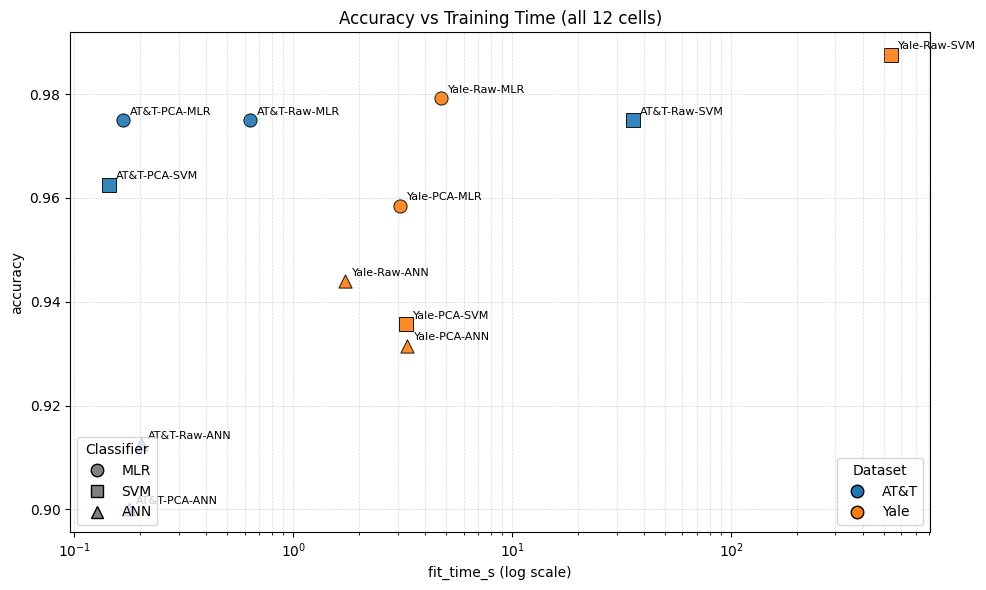

In [86]:
# §8.1 Accuracy vs Training Time scatter plot
marker_by_classifier = {"MLR": "o", "SVM": "s", "ANN": "^"}
color_by_dataset = {"AT&T": TAB10(0), "Yale": TAB10(1)}
plot_df = master_df.copy()
plot_df["fit_time_s"] = plot_df["fit_time_s"].astype(float)
plot_df["accuracy"] = plot_df["accuracy"].astype(float)
plot_df["cell_label"] = (
    plot_df["dataset"].astype(str)
    + "-"
    + plot_df["feature"].astype(str)
    + "-"
    + plot_df["classifier"].astype(str)
)

fig, ax = plt.subplots(figsize=(10, 6))
for _, row in plot_df.iterrows():
    ax.scatter(
        row["fit_time_s"],
        row["accuracy"],
        marker=marker_by_classifier[row["classifier"]],
        color=color_by_dataset[row["dataset"]],
        edgecolor="black",
        linewidth=0.7,
        s=90,
        alpha=0.9,
    )
    ax.annotate(
        row["cell_label"],
        (row["fit_time_s"], row["accuracy"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8,
    )

ax.set_xscale("log")
ax.set_xlabel("fit_time_s (log scale)")
ax.set_ylabel("accuracy")
ax.set_title("Accuracy vs Training Time (all 12 cells)")
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)

classifier_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        color="white",
        markerfacecolor="gray",
        markeredgecolor="black",
        linestyle="None",
        markersize=9,
        label=classifier,
    )
    for classifier, marker in marker_by_classifier.items()
]
dataset_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="white",
        markerfacecolor=color,
        markeredgecolor="black",
        linestyle="None",
        markersize=9,
        label=dataset,
    )
    for dataset, color in color_by_dataset.items()
]
legend_1 = ax.legend(handles=classifier_handles, title="Classifier", loc="lower left")
ax.add_artist(legend_1)
ax.legend(handles=dataset_handles, title="Dataset", loc="lower right")
plt.tight_layout()
plt.show()

accuracies = plot_df["accuracy"].to_numpy(dtype=float)
log_times = np.log10(plot_df["fit_time_s"].to_numpy(dtype=float))
plot_df["pareto_efficient"] = [
    not any(
        (other.accuracy >= point.accuracy)
        and (other.fit_time_s <= point.fit_time_s)
        and ((other.accuracy > point.accuracy) or (other.fit_time_s < point.fit_time_s))
        for other in plot_df.itertuples(index=False)
    )
    for point in plot_df.itertuples(index=False)
]
pareto_df = plot_df[plot_df["pareto_efficient"]].copy()
accuracy_range = accuracies.max() - accuracies.min()
log_time_range = log_times.max() - log_times.min()
pareto_df["norm_accuracy"] = (
    (pareto_df["accuracy"] - accuracies.min()) / accuracy_range
    if accuracy_range > 0
    else 1.0
)
pareto_df["norm_speed"] = (
    (log_times.max() - np.log10(pareto_df["fit_time_s"])) / log_time_range
    if log_time_range > 0
    else 1.0
)
pareto_df["tradeoff_score"] = np.where(
    (pareto_df["norm_accuracy"] + pareto_df["norm_speed"]) > 0,
    2
    * pareto_df["norm_accuracy"]
    * pareto_df["norm_speed"]
    / (pareto_df["norm_accuracy"] + pareto_df["norm_speed"]),
    0.0,
)
best_tradeoff = pareto_df.sort_values(
    ["tradeoff_score", "accuracy", "fit_time_s"],
    ascending=[False, False, True],
).iloc[0]
pareto_labels = ", ".join(pareto_df.sort_values("fit_time_s")["cell_label"])


#### §7.1 Accuracy-Time Scatter 結果解讀

Accuracy-time 散點圖將十二個實驗單元投影至相同的表現與成本權衡平面。Pareto frontier 揭示，最高準確率、最低訓練時間與最佳準確率–時間折衷通常分屬不同實驗單元；模型選擇遂須依部署目標而定，而非僅憑單一 accuracy 指標進行比較。

該散點圖的診斷功能在於呈現在不同部署目標下模型選擇的對應關係。若以 Yale 資料集之最高準確率為優先，raw SVM 通常表現最優，然其時間成本亦最高；若需避免高維 raw SVM 的長訓練時間，MLR 於 raw 特徵與各 PCA-based 模型提供較實用的替代方案；若以快速且穩定之線性基準為目標，MLR 搭配 PCA 的組合仍展現效率優勢。

# §8 總結論

綜觀十二個實驗單元於 AT&T 與 Yale 資料集上之系統性比較，shallow classifiers 的分類表現主要受制於特徵空間與資料結構間的匹配程度，而非模型容量本身之上限。PCA 所壓縮之變異類型、最佳化預算的充足性，以及成像條件對線性邊界的支撐強度，三者共同形塑各實驗單元間的結果差異。

PCA 對分類準確率的效益取決於資料集特性、分類器形式與最佳化設定，而非呈現單一方向之效果。於 AT&T 資料集中，主要身分訊號集中於少數主成分，PCA 通常能保留 MLR 所需之線性資訊，並附帶降低計算成本；Yale Face B 則因光照方向與陰影變化佔據主要變異來源，須搭配較高維之 PCA 表徵與穩定的優化器，方能維持身分辨識表現。

三個分類器間展現明確的權衡關係：SVM 提供最高可達之準確率，然於 raw 高維特徵上之訓練成本亦最高；ANN 在 Yale 資料集上以可控的訓練時間提供非線性表徵能力；MLR 則作為可解釋性最佳之線性基準。手刻 `MyMLR` 的驗證結果應理解為 full-batch gradient descent 對迭代預算與正則化設定之敏感性，而非 PCA 表徵本身的判別上限。

與 Work2 中 SVD 重建分析的連結進一步確認，像素層級之重建品質與分類效用並不等價：重建誤差可隨主成分數 $k$ 之增加而持續下降，然分類準確率曲線可能較早進入飽和階段。分類器所需者為具判別力之投影方向，而非完整保留所有像素細節。本實驗之主要限制在於 shallow 模型對光照變異的處理能力存在上限；局部特徵學習或大規模預訓練特徵或可改善此問題，惟相關探討已超出本作業範圍。